# Foundations of adaptive peer routing dynamics

## Part 1. Foundations of a simple router simulation

First is a two-state model implementation and simulation as the starting point. 

**Interpretation boundary.** The Gaussian equations describe a surrogate: the example actually samples binary failures, clips estimates, and advances uncertainty and small latency drift only for the selected peer. The trace bonus is an exploration incentive, not a risk penalty. The displayed bands are clipped one-standard-deviation bands, not validated confidence intervals. A timeout is mentioned in the original description but is not implemented. The single trajectory cannot establish comparative performance or calibration.

Parts 2–8 introduce explicit mathematical corrections, verification tests, paired experiments, likelihood-aware estimation, sensitivity analysis, delayed feedback, task-dependent capabilities, and an interpretable latency-reliability trade-off. All new results concern a **local router and synthetic workers**. They do not measure a decentralized mesh or live language models.

The router role functions as a localized epistemic engine. Rather than relying on static capabilities, it continuously tracks the hidden cognitive and physical states of its neighboring LM worker peers using a discrete-time Kalman filter.

For each peer $i$, the router maintains a belief over a hidden state vector $\mathbf{x}_{k}^{(i)}$, representing the true physical latency and functional error rate at time step $k$:

$$
\mathbf{x}_k = \begin{bmatrix} l_k \\ \eta_k \end{bmatrix} \quad \text{(latency, error rate)}
$$

Because hardware and network conditions drift naturally over time, the state evolves according to a linear stochastic difference equation governed by process noise $\mathbf{w}_k \sim \mathcal{N}(0, \mathbf{Q})$:

$$
\mathbf{x}_k = \mathbf{x}_{k-1} + \mathbf{w}_{k-1}
$$

When the router dispatches a task to a peer, it receives a programmatic verification payload as a noisy measurement $\mathbf{z}_k$. The measurement is corrupted by observation noise $\mathbf{v}_k \sim \mathcal{N}(0, \mathbf{R})$:

$$
\mathbf{z}_k = \mathbf{x}_k + \mathbf{v}_k
$$

### Router belief update equations

Upon receiving a response (or a timeout), the router updates its belief state ($\hat{\mathbf{x}}$) and covariance matrix ($\mathbf{P}$) using the standard Kalman equations.

**1. Predict (A priori state estimate):**
$$
\hat{\mathbf{x}}_{k|k-1} = \hat{\mathbf{x}}_{k-1|k-1}
$$
$$
\mathbf{P}_{k|k-1} = \mathbf{P}_{k-1|k-1} + \mathbf{Q}
$$

**2. Update (A posteriori state estimate):**
The router calculates the Kalman gain $\mathbf{K}_k$, balancing its current uncertainty against the variance of the incoming measurement:
$$
\mathbf{K}_k = \mathbf{P}_{k|k-1} (\mathbf{P}_{k|k-1} + \mathbf{R})^{-1}
$$
$$
\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k (\mathbf{z}_k - \hat{\mathbf{x}}_{k|k-1})
$$
$$
\mathbf{P}_{k|k} = (\mathbf{I} - \mathbf{K}_k) \mathbf{P}_{k|k-1}
$$

### The routing cost function

To balance exploiting historically reliable nodes with exploring potentially recovered nodes, the router minimizes a cost function $J$ penalized by the trace of the covariance matrix (representing epistemic uncertainty):

$$
J^{(i)} = \hat{l}^{(i)} + \lambda \hat{\eta}^{(i)} - \beta \sqrt{\text{Tr}(\mathbf{P}^{(i)})}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd


# defining the original system

# defining the illustrative Kalman parameters
# using elevated process variance in the original illustration
Q = np.array([[0.05, 0.0],    # representing latency process variance
              [0.0, 0.02]])   # representing error-rate process variance

R = np.array([[0.2, 0.0],     # representing latency observation variance
              [0.0, 0.15]])   # approximating binary-outcome observation variance

def kalman_update(x_hat, P, z, Q, R):
    # predicting the selected peer state
    P_pred = P + Q

    # updating the selected peer belief
    S = P_pred + R
    K = P_pred @ np.linalg.inv(S)

    x_hat_new = x_hat + K @ (z - x_hat)
    P_new = (np.eye(2) - K) @ P_pred

    # clipping estimates to the physical support in this illustration
    x_hat_new[0, 0] = max(0.01, x_hat_new[0, 0])  # keeping estimated latency positive
    x_hat_new[1, 0] = np.clip(x_hat_new[1, 0], 0.0, 1.0) # keeping the estimated probability within its support

    return x_hat_new, P_new

class WorkerPeer:
    def __init__(self, name, base_latency, base_error, node_type):
        self.name = name
        self.base_latency = base_latency
        self.base_error = base_error
        self.node_type = node_type
        self.current_latency = base_latency
        self.current_error = base_error

    def execute_task(self):
        # sampling latency variation
        latency_noise = np.random.normal(0, 0.1) if self.node_type == 'heavy' else np.random.normal(0, 0.3)
        actual_latency = max(0.1, self.current_latency + latency_noise)

        # sampling a binary failure from the current probability
        actual_error = float(np.random.binomial(1, self.current_error))

        return np.array([[actual_latency], [actual_error]])

    def trigger_environmental_shock(self, new_latency, new_error):
        """simulating 'hardware' throttling or context saturation in the network."""
        self.current_latency = new_latency
        self.current_error = new_error

# fixing the illustrative seed independently of the research experiments
np.random.seed(20260924)

In [2]:
# executing the original simulation

NUM_STEPS = 150
BETA = 1.5   # setting the exploration coefficient
LAMBDA = 8.0 # setting the failure penalty

workers = {
    "W1 (Heavy)": WorkerPeer("W1 (Heavy)", base_latency=1.2, base_error=0.05, node_type='heavy'),
    "W2 (Heavy)": WorkerPeer("W2 (Heavy)", base_latency=1.8, base_error=0.10, node_type='heavy'),
    "W3 (Edge)":  WorkerPeer("W3 (Edge)", base_latency=0.3, base_error=0.40, node_type='edge'),
    "W4 (Edge)":  WorkerPeer("W4 (Edge)", base_latency=0.5, base_error=0.30, node_type='edge')
}

# initializing high-uncertainty beliefs
beliefs = {w: (np.array([[1.0], [0.5]]), np.eye(2) * 5.0) for w in workers.keys()}

# allocating simulation history
history = {w: {'tasks': 0, 'error_est': [], 'error_var': [], 'true_error': []} for w in workers.keys()}
traffic_log = []

for step in range(NUM_STEPS):
    # introducing an exogenous shock
    # degrading W1 at round 75
    if step == 75:
        workers["W1 (Heavy)"].trigger_environmental_shock(new_latency=4.0, new_error=0.85)
        # improving W4 at the same round
        workers["W4 (Edge)"].trigger_environmental_shock(new_latency=0.4, new_error=0.05)

    best_cost = float('inf')
    selected_worker = None

    for w_name, (x_hat, P) in beliefs.items():
        lat_est, err_est = x_hat[0, 0], x_hat[1, 0]
        uncertainty = np.sqrt(np.trace(P))

        cost = lat_est + (LAMBDA * err_est) - (BETA * uncertainty)
        if cost < best_cost:
            best_cost = cost
            selected_worker = w_name

    # executing a task and updating the selected peer
    z_measurement = workers[selected_worker].execute_task()
    old_x, old_P = beliefs[selected_worker]
    new_x, new_P = kalman_update(old_x, old_P, z_measurement, Q, R)
    beliefs[selected_worker] = (new_x, new_P)

    # recording numerical simulation outcomes
    workers[selected_worker].current_latency += np.random.normal(0, 0.02) # applying the original selected-peer drift
    history[selected_worker]['tasks'] += 1
    traffic_log.append(selected_worker)

    for w_name, (x_hat, P) in beliefs.items():
        history[w_name]['error_est'].append(x_hat[1, 0])
        history[w_name]['error_var'].append(P[1, 1])
        history[w_name]['true_error'].append(workers[w_name].current_error)

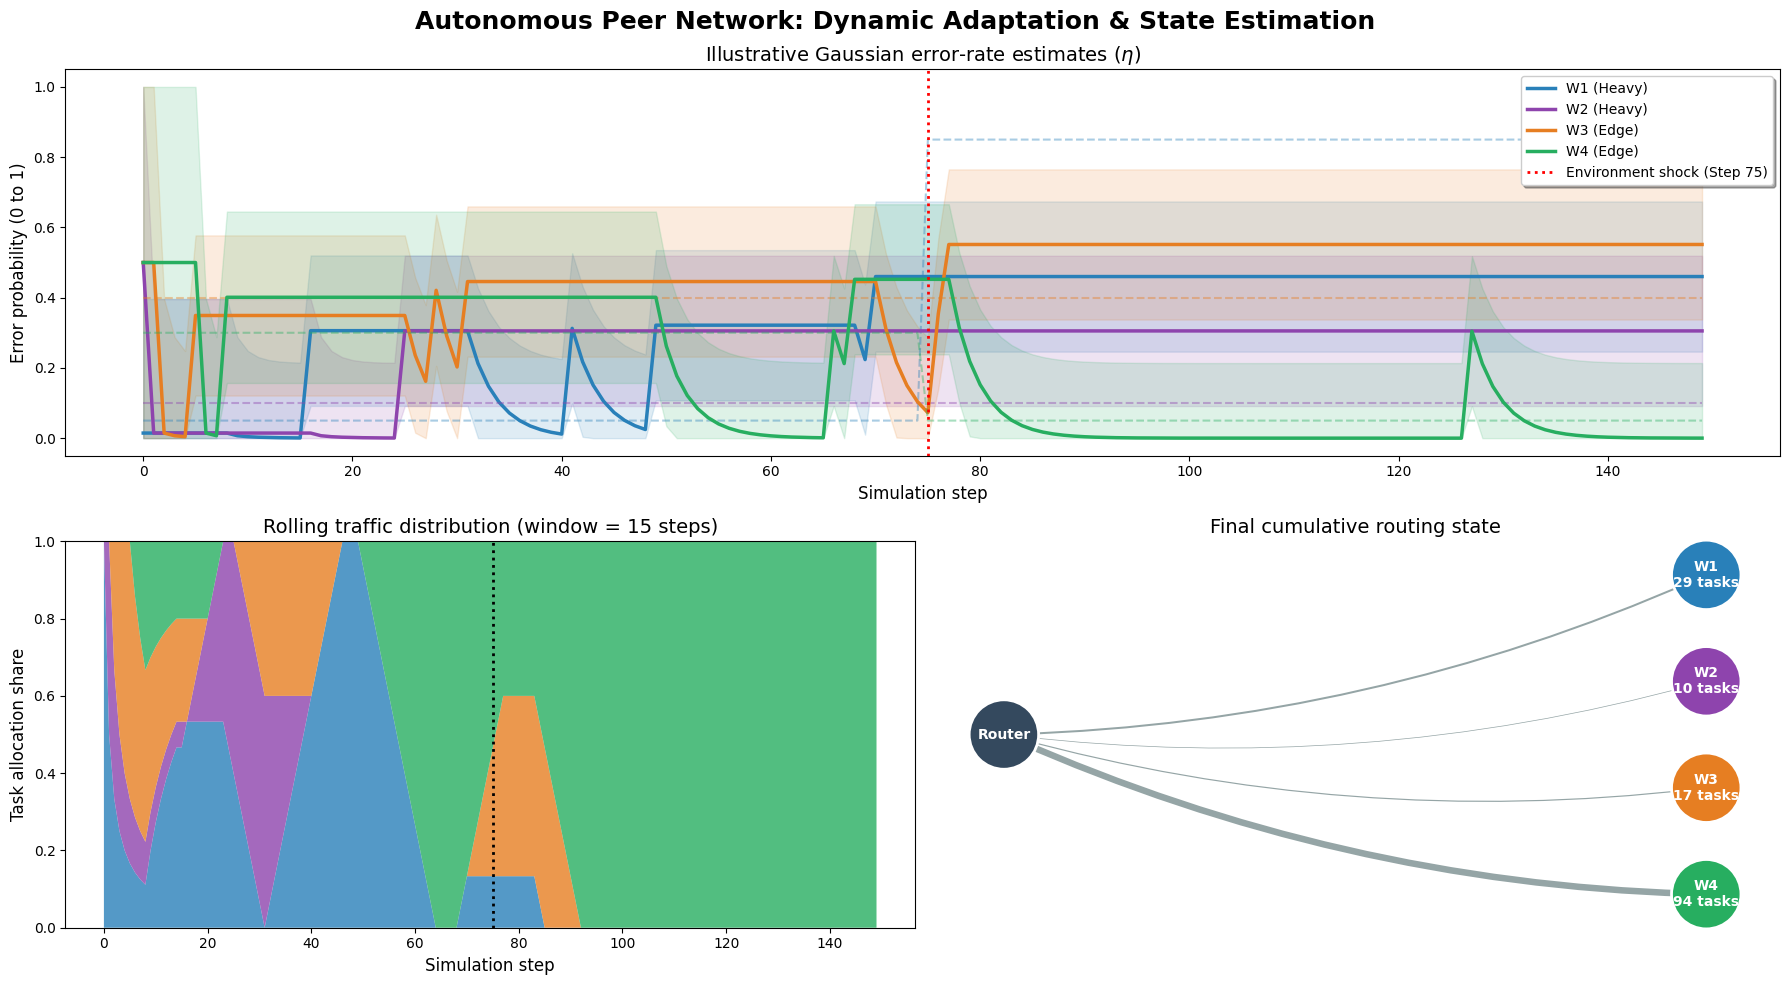

In [3]:
# visualizing the original simulation

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Autonomous Peer Network: Dynamic Adaptation & State Estimation', fontsize=18, fontweight='bold', y=0.98)

colors = {'W1 (Heavy)': '#2980b9', 'W2 (Heavy)': '#8e44ad', 'W3 (Edge)': '#e67e22', 'W4 (Edge)': '#27ae60'}

# plotting error estimates with illustrative uncertainty bands
ax1 = plt.subplot(2, 2, (1, 2))
ax1.set_title(r"Illustrative Gaussian error-rate estimates ($\eta$)", fontsize=14)

steps = np.arange(NUM_STEPS)
for w in workers.keys():
    est = np.array(history[w]['error_est'])
    var = np.array(history[w]['error_var'])
    std = np.sqrt(var)

    # plotting the true probability as a dashed line
    ax1.plot(steps, history[w]['true_error'], color=colors[w], linestyle='--', alpha=0.4, linewidth=1.5)
    # plotting the belief mean
    ax1.plot(steps, est, color=colors[w], label=w, linewidth=2.5)
    # shading clipped one-standard-deviation bands
    ax1.fill_between(steps, np.clip(est - std, 0, 1), np.clip(est + std, 0, 1), color=colors[w], alpha=0.15)

ax1.axvline(x=75, color='red', linestyle=':', linewidth=2, label='Environment shock (Step 75)')
ax1.set_ylabel("Error probability (0 to 1)", fontsize=12)
ax1.set_xlabel("Simulation step", fontsize=12)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper right', frameon=True, shadow=True)

# plotting rolling task allocation
ax2 = plt.subplot(2, 2, 3)
ax2.set_title("Rolling traffic distribution (window = 15 steps)", fontsize=14)

# calculating rolling allocation shares
df_traffic = pd.DataFrame({'worker': traffic_log})
df_dummies = pd.get_dummies(df_traffic['worker'])
# including workers receiving zero tasks
for w in workers.keys():
    if w not in df_dummies.columns:
        df_dummies[w] = 0
df_dummies = df_dummies[list(workers.keys())]

rolling_shares = df_dummies.rolling(window=15, min_periods=1).mean()

ax2.stackplot(steps, [rolling_shares[w] for w in workers.keys()],
              labels=workers.keys(), colors=[colors[w] for w in workers.keys()], alpha=0.8)
ax2.axvline(x=75, color='black', linestyle=':', linewidth=2)
ax2.set_ylabel("Task allocation share", fontsize=12)
ax2.set_xlabel("Simulation step", fontsize=12)
ax2.set_ylim(0, 1)

# plotting the local router-to-worker topology
ax3 = plt.subplot(2, 2, 4)
ax3.set_title("Final cumulative routing state", fontsize=14)
ax3.axis('off')

G = nx.DiGraph()
G.add_node("Router", pos=(0, 0.5))
for i, w in enumerate(workers.keys()):
    y_pos = 0.8 - (i * 0.2)
    G.add_node(w, pos=(1, y_pos))
    G.add_edge("Router", w, weight=history[w]['tasks'])

pos = nx.get_node_attributes(G, 'pos')
node_colors = ['#34495e'] + [colors[w] for w in workers.keys()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, ax=ax3, edgecolors='white', linewidths=2)

# scaling edge widths by task counts
edges = G.edges()
weights = [G[u][v]['weight'] * 0.05 for u, v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='#95a5a6',
                       arrowsize=15, connectionstyle='arc3,rad=0.1', ax=ax3)

# adding peer labels and task counts
labels = {"Router": "Router"}
for w in workers.keys():
    labels[w] = f"{w.split(' ')[0]}\n{history[w]['tasks']} tasks"
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white', font_weight='bold', ax=ax3)

plt.tight_layout()
plt.show()

## Part 2. Mathematical consistency and executable verification

**Question.** Does the implementation match the information available to the router and the uncertainty implied by the model?

### Elapsed-time prediction and cost uncertainty

Let $s_i$ be the sampling time of the most recent assimilated observation of peer $i$. Under the random-walk surrogate, prediction to decision time $t$ is

$$\hat x_{t|s_i}^{(i)}=\hat x_{s_i|s_i}^{(i)},\qquad
P_{t|s_i}^{(i)}=P_{s_i|s_i}^{(i)}+(t-s_i)Q.$$

This lazy representation is equivalent to predicting **every peer at every elapsed round**. Querying the belief does not mutate it. An observation sampled at $s$ updates the belief at $s$, after which prediction resumes toward the current decision time. Fixed feedback delays preserve each peer's observation order; duplicate or out-of-order messages are rejected rather than misassimilated. Arbitrary reordering would require replay or smoothing.

For $c=(1,\lambda)^\top$, the expected-cost uncertainty is

$$\sigma_{J,i}^2=c^\top P_i c=P_{ll}^{(i)}+2\lambda P_{l\eta}^{(i)}+\lambda^2P_{\eta\eta}^{(i)},\qquad
J_i=c^\top\hat x_i-\beta\sqrt{c^\top P_i c}.$$

The negative term implements **optimism for cost minimization**. It is not a safety guarantee or a penalty for uncertainty. If latency is measured in seconds, $\lambda$ converts a failure probability into equivalent seconds. Unlike an unweighted trace, $c^\top P c$ follows that cost scale. Converting seconds to milliseconds and scaling $\lambda$ accordingly multiplies the whole score by 1000 without changing its ordering.

**Derived property.** For an unobserved peer, projected variance grows by $(t-s_i)c^\top Qc$. With positive projected process noise and a fixed mean, its optimistic score decreases with its age. This is a mechanism for revisiting stale peers, not a proof of low regret: poorly calibrated uncertainty can also cause excessive exploration.

The full-covariance reference update uses a linear solve and the Joseph identity

$$P^+=(I-K)P^-(I-K)^\top+KRK^\top.$$

The benchmark uses its diagonal specialization because the original model assumes independent state dimensions. Full-covariance algebra is tested, but correlated-state routing performance is not evaluated here. Linear-Gaussian filtering and numerical covariance updates follow established methods [1, 5, 6].

### An explicit observation model

The research environment generates positive latency and binary failures:

$$L_{t,i}=l_{t,i}\exp(\sigma_i\epsilon_{t,i}-\sigma_i^2/2),\quad
Y_{t,i}\sim\operatorname{Bernoulli}(\eta_{t,i}),\quad \epsilon_{t,i}\sim N(0,1).$$

Thus $E[L_{t,i}]=l_{t,i}$. This deliberately replaces the original clipped-normal latency generator, whose clipping changes its expectation. Every peer's trajectory and potential observations are generated **before** a routing policy is run. Policies receive only selected-peer feedback; latent states and counterfactual outcomes remain evaluator-only data. Drift is exogenous and advances for all peers, not only those selected.

Two estimator families are compared. **KF cost-LCB** keeps the two-dimensional Gaussian approximation, with fixed observation variances that are not claimed to match Bernoulli or heteroscedastic lognormal noise. **Hybrid cost-LCB** uses a scalar Gaussian filter on log mean latency, observing $\log L+\sigma_i^2/2$, and Beta-Bernoulli error counts. With elapsed time $\Delta$ and discount $\gamma$,

$$a^-=1+\gamma^\Delta(a-1),\quad b^-=1+\gamma^\Delta(b-1),\qquad
(a^+,b^+)=(a^-+Y,b^-+1-Y).$$

With $\gamma=1$ and a constant error probability, these are exact Beta-Bernoulli updates. With forgetting, they are a discounted-evidence heuristic, **not** an exact posterior for a specified evolving probability process. Beta interval coverage is therefore measured, not assumed. The hybrid knows the synthetic latency-jitter scale; estimating that scale from real observations remains outside this experiment.

### Reproducibility and numerical primitives

The seed sets are disjoint. `HORIZON` controls each routing run; sample sizes are explicit rather than hidden behind a “publication” mode. Installed package versions are displayed at the end.

In [4]:
from dataclasses import dataclass, replace
from collections import deque
import heapq
import platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_distribution, chi2, norm, t as student_t
from scipy.special import expit, logit
from IPython.display import display


MASTER_SEED = 20260924
TEST_SEEDS = tuple(range(1000, 1032))
VALIDATION_SEEDS = tuple(range(2000, 2012))
STRESS_SEEDS = tuple(range(3000, 3016))
CONFIRMATION_SEEDS = tuple(range(5000, 5032))
HORIZON = 600
LAMBDA_COST = 8.0
PEER_NAMES = ("W1 (Heavy)", "W2 (Heavy)", "W3 (Edge)", "W4 (Edge)")


def seeded_rng(seed: int, stream: int) -> np.random.Generator:
    return np.random.default_rng(np.random.SeedSequence([MASTER_SEED, seed, stream]))


def joseph_update(mean, covariance, observation, noise):
    """updating a full-covariance Gaussian belief for an identity observation map."""
    mean, covariance, observation, noise = map(
        lambda value: np.asarray(value, dtype=float),
        (mean, covariance, observation, noise),
    )
    dimension = mean.size
    if mean.shape != (dimension,) or observation.shape != mean.shape:
        raise ValueError("mean and observation must be one-dimensional and equally sized")
    if covariance.shape != (dimension, dimension) or noise.shape != covariance.shape:
        raise ValueError("covariance and noise must match the state dimension")
    for matrix, label in ((covariance, "covariance"), (noise, "noise")):
        if not np.all(np.isfinite(matrix)) or not np.allclose(matrix, matrix.T):
            raise ValueError(f"{label} must be finite and symmetric")
        if np.linalg.eigvalsh(matrix).min() < -1e-12:
            raise ValueError(f"{label} must be positive semidefinite")
    innovation = observation - mean
    innovation_covariance = covariance + noise
    gain = np.linalg.solve(innovation_covariance, covariance.T).T
    residual_map = np.eye(dimension) - gain
    posterior_covariance = (
        residual_map @ covariance @ residual_map.T + gain @ noise @ gain.T
    )
    posterior_covariance = (posterior_covariance + posterior_covariance.T) / 2
    nis = float(innovation @ np.linalg.solve(innovation_covariance, innovation))
    return mean + gain @ innovation, posterior_covariance, nis


def projected_cost_sd(covariance: np.ndarray, penalty: float) -> np.ndarray:
    weights = np.array([1.0, penalty])
    variance = np.einsum("i,...ij,j->...", weights, covariance, weights)
    if np.any(variance < -1e-10):
        raise ValueError("projected variances cannot be negative")
    return np.sqrt(np.maximum(variance, 0.0))

### Policy-independent environments

`stationary` preserves the initial peer characteristics. `shock` reproduces the W1 degradation and W4 improvement halfway through the horizon. `drift` uses Gaussian random walks in log latency and logit failure probability. `recovery` degrades and later restores W1. `contextual` introduces two observable task types and changes their arrival mixture halfway through the horizon.

In [5]:
@dataclass(frozen=True)
class World:
    scenario: str
    means: np.ndarray
    outcomes: np.ndarray
    contexts: np.ndarray
    log_sigma: np.ndarray
    changes: tuple[int, ...]

    @property
    def steps(self):
        return self.means.shape[0]

    @property
    def peers(self):
        return self.means.shape[1]

    @property
    def context_count(self):
        return self.means.shape[2]

    def expected_costs(self, penalty: float) -> np.ndarray:
        current = self.means[np.arange(self.steps), :, self.contexts, :]
        return current[..., 0] + penalty * current[..., 1]


def make_world(seed: int, scenario: str = "shock", steps: int = HORIZON,
               noise_scale: float = 1.0) -> World:
    """generating immutable, policy-independent potential outcomes for every peer."""
    if steps < 20 or noise_scale <= 0:
        raise ValueError("steps must be at least 20 and noise_scale must be positive")
    if scenario not in {"stationary", "shock", "drift", "recovery", "contextual"}:
        raise ValueError(f"unknown scenario: {scenario}")
    base = np.array([[1.2, .05], [1.8, .10], [.3, .40], [.5, .30]])
    context_count = 2 if scenario == "contextual" else 1
    means = np.broadcast_to(base[None, :, None, :], (steps, 4, context_count, 2)).copy()
    changes = ()
    if scenario == "shock":
        changes = (steps // 2,)
        means[changes[0]:, 0, 0] = [4.0, .85]
        means[changes[0]:, 3, 0] = [.4, .05]
    elif scenario == "recovery":
        changes = (steps // 3, 2 * steps // 3)
        means[changes[0]:changes[1], 0, 0] = [4.0, .85]
    elif scenario == "drift":
        drift_rng = seeded_rng(seed, 10)
        latent = np.stack([np.log(base[:, 0]), logit(base[:, 1])], axis=-1)
        increments = drift_rng.normal(size=(steps - 1, 4, 2)) * [.025, .08]
        path = np.concatenate([latent[None], latent[None] + np.cumsum(increments, axis=0)])
        means[:, :, 0, 0] = np.exp(path[..., 0])
        means[:, :, 0, 1] = expit(path[..., 1])
    elif scenario == "contextual":
        means[:, :, :, 0] = np.array([1.2, 1.0, .3, .4])[None, :, None]
        means[:, :, :, 1] = np.array([[.05, .55], [.55, .05], [.20, .45], [.45, .20]])
        changes = (steps // 2,)
    context_rng = seeded_rng(seed, 11)
    if context_count == 2:
        probability_context_zero = np.where(np.arange(steps) < steps // 2, .5, .85)
        contexts = (context_rng.random(steps) >= probability_context_zero).astype(int)
    else:
        contexts = np.zeros(steps, dtype=int)
    log_sigma = noise_scale * np.array([.10, .10, .35, .35])
    observation_rng = seeded_rng(seed, 12)
    gaussian_noise = observation_rng.normal(size=(steps, 4, context_count))
    uniform_noise = observation_rng.random(size=(steps, 4, context_count))
    sigma = log_sigma[None, :, None]
    latency = means[..., 0] * np.exp(sigma * gaussian_noise - .5 * sigma**2)
    failures = (uniform_noise < means[..., 1]).astype(float)
    outcomes = np.stack([latency, failures], axis=-1)
    for array in (means, outcomes, contexts, log_sigma):
        array.setflags(write=False)
    return World(scenario, means, outcomes, contexts, log_sigma, changes)

### Routing policies

The static baseline calibrates each peer on five tasks and freezes its estimates. EWMA uses recency-weighted costs with epsilon-greedy exploration. Window LCB uses only recently sampled feedback and forces exploration when a peer has no observation in the current global-time window. It is a **sliding-window optimism baseline inspired by** nonstationary UCB work [2], not a reproduction of that paper or an invocation of its guarantees: costs here are unbounded because latency is lognormal.

In [6]:
@dataclass(frozen=True)
class PolicySpec:
    name: str
    kind: str = "kalman"
    beta: float = .5
    q_scale: float = 1.0
    r_scale: float = 1.0
    discount: float = .97
    epsilon: float = .10
    alpha: float = .15
    window: int = 100
    aging: bool = True
    uncertainty: str = "cost"
    contextual: bool = False

    def __post_init__(self):
        if self.kind not in {"kalman", "hybrid", "random", "round_robin", "static", "ewma", "window"}:
            raise ValueError("unknown policy kind")
        if self.beta < 0 or self.q_scale < 0 or self.r_scale <= 0:
            raise ValueError("invalid uncertainty parameters")
        if not 0 < self.discount <= 1 or not 0 <= self.epsilon <= 1 or not 0 < self.alpha <= 1:
            raise ValueError("invalid discount, epsilon, or alpha")
        if self.window < 1 or self.uncertainty not in {"cost", "trace"}:
            raise ValueError("invalid window or uncertainty projection")


class RoutingPolicy:
    """maintaining beliefs using only timestamped feedback from selected peers."""

    def __init__(self, spec: PolicySpec, peers: int, contexts: int,
                 log_sigma: np.ndarray, penalty: float, seed: int):
        self.spec, self.peers, self.penalty = spec, peers, float(penalty)
        if self.penalty < 0:
            raise ValueError("penalty must be nonnegative")
        self.contexts = contexts if spec.contextual else 1
        self.rng = seeded_rng(seed, 20)
        shape = (peers, self.contexts)
        self.mean = np.broadcast_to([1.0, .5], shape + (2,)).copy()
        self.variance = np.broadcast_to([1.0, 1 / 12], shape + (2,)).copy()
        self.stamp = np.zeros(shape, dtype=int)
        self.seen = np.zeros(shape, dtype=int)
        self.q = spec.q_scale * np.array([.005, .002])
        self.r = spec.r_scale * np.array([.20, .15])
        self.log_mean = np.zeros(shape)
        self.log_variance = np.full(shape, .25)
        self.log_q = spec.q_scale * .001
        self.log_r = np.asarray(log_sigma)**2 * spec.r_scale
        self.failure_count = np.ones(shape)
        self.success_count = np.ones(shape)
        self.cost_estimate = np.full(shape, 1 + .5 * self.penalty)
        self.count = np.zeros(shape, dtype=int)
        self.window_data = [[deque() for _ in range(self.contexts)] for _ in range(peers)]
        self.context_visits = np.zeros(self.contexts, dtype=int)
        self.calibration_samples = set()

    def _context(self, context: int) -> int:
        return context if self.spec.contextual else 0

    def _beta_parameters(self, time: int, context: int):
        c = self._context(context)
        age = time - self.stamp[:, c]
        if np.any(age < 0):
            raise ValueError("feedback timestamps must be nondecreasing for each belief")
        decay = self.spec.discount**age
        a = 1 + decay * (self.failure_count[:, c] - 1)
        b = 1 + decay * (self.success_count[:, c] - 1)
        return a, b

    def belief(self, time: int, context: int):
        c = self._context(context)
        age = time - self.stamp[:, c]
        if np.any(age < 0):
            raise ValueError("cannot query a belief before its latest feedback timestamp")
        if self.spec.kind == "hybrid":
            log_variance = self.log_variance[:, c] + age * self.log_q
            latency_mean = np.exp(self.log_mean[:, c] + .5 * log_variance)
            latency_variance = np.expm1(log_variance) * latency_mean**2
            a, b = self._beta_parameters(time, context)
            error_mean = a / (a + b)
            error_variance = a * b / ((a + b)**2 * (a + b + 1))
            return np.column_stack([latency_mean, error_mean]), np.column_stack([latency_variance, error_variance])
        variance = self.variance[:, c].copy()
        if self.spec.aging:
            variance += age[:, None] * self.q
        return self.mean[:, c].copy(), variance

    def error_interval(self, time: int, context: int, level: float = .95):
        if not 0 < level < 1:
            raise ValueError("level must be between zero and one")
        if self.spec.kind == "hybrid":
            a, b = self._beta_parameters(time, context)
            return beta_distribution.ppf((1 - level) / 2, a, b), beta_distribution.ppf((1 + level) / 2, a, b)
        mean, variance = self.belief(time, context)
        width = norm.ppf((1 + level) / 2) * np.sqrt(variance[:, 1])
        return np.maximum(0, mean[:, 1] - width), np.minimum(1, mean[:, 1] + width)

    def _choose_minimum(self, score):
        candidates = np.flatnonzero(np.isclose(score, np.min(score), atol=1e-12, rtol=1e-12))
        return int(self.rng.choice(candidates)) if len(candidates) > 1 else int(candidates[0])

    def select(self, time: int, context: int) -> int:
        spec, c = self.spec, self._context(context)
        visit = int(self.context_visits[c])
        self.context_visits[c] += 1
        if spec.kind == "random":
            return int(self.rng.integers(self.peers))
        if spec.kind == "round_robin":
            return visit % self.peers
        if spec.kind == "static":
            if visit < 5 * self.peers:
                self.calibration_samples.add((time, c, visit % self.peers))
                return visit % self.peers
            return self._choose_minimum(self.cost_estimate[:, c])
        if spec.kind == "ewma":
            if visit < self.peers:
                return visit % self.peers
            if self.rng.random() < spec.epsilon:
                return int(self.rng.integers(self.peers))
            return self._choose_minimum(self.cost_estimate[:, c])
        if spec.kind == "window":
            score = np.empty(self.peers)
            for peer in range(self.peers):
                observations = self.window_data[peer][c]
                while observations and observations[0][0] < time - spec.window:
                    observations.popleft()
                if observations:
                    values = np.array([value for _, value in observations])
                    score[peer] = values.mean() - spec.beta * (1 + self.penalty) * np.sqrt(
                        np.log(max(2, min(time + 1, spec.window))) / len(values)
                    )
                else:
                    score[peer] = -np.inf
            return self._choose_minimum(score)
        mean, variance = self.belief(time, context)
        cost_mean = mean[:, 0] + self.penalty * mean[:, 1]
        if spec.uncertainty == "trace":
            cost_sd = np.sqrt(variance.sum(axis=1))
        else:
            cost_sd = np.sqrt(variance[:, 0] + self.penalty**2 * variance[:, 1])
        return self._choose_minimum(cost_mean - spec.beta * cost_sd)

    def observe(self, sample_time: int, context: int, peer: int, observation):
        """updating at the sampling time, rather than pretending delayed feedback is current."""
        spec, c = self.spec, self._context(context)
        latency, failure = map(float, observation)
        if latency <= 0 or failure not in (0.0, 1.0):
            raise ValueError("routing observations require positive latency and binary failure")
        if self.seen[peer, c] and sample_time <= self.stamp[peer, c]:
            raise ValueError("out-of-order or duplicate feedback requires a replay filter")
        self.seen[peer, c] += 1
        if spec.kind in {"random", "round_robin", "static", "ewma", "window"}:
            self.stamp[peer, c] = sample_time
        if spec.kind in {"random", "round_robin"}:
            return
        cost = latency + self.penalty * failure
        if spec.kind == "static":
            if (sample_time, c, peer) in self.calibration_samples:
                self.count[peer, c] += 1
                self.cost_estimate[peer, c] += (cost - self.cost_estimate[peer, c]) / self.count[peer, c]
            return
        if spec.kind == "ewma":
            self.count[peer, c] += 1
            gain = 1.0 if self.count[peer, c] == 1 else spec.alpha
            self.cost_estimate[peer, c] += gain * (cost - self.cost_estimate[peer, c])
            return
        if spec.kind == "window":
            self.window_data[peer][c].append((sample_time, cost))
            return
        age = sample_time - self.stamp[peer, c]
        if age < 0:
            raise ValueError("negative elapsed time")
        if spec.kind == "hybrid":
            prior_variance = self.log_variance[peer, c] + age * self.log_q
            gain = prior_variance / (prior_variance + self.log_r[peer])
            # correcting the lognormal observation so its expectation equals log mean latency
            adjusted_log_latency = np.log(latency) + .5 * self.log_r[peer] / spec.r_scale
            self.log_mean[peer, c] += gain * (adjusted_log_latency - self.log_mean[peer, c])
            self.log_variance[peer, c] = (1 - gain)**2 * prior_variance + gain**2 * self.log_r[peer]
            decay = spec.discount**age
            self.failure_count[peer, c] = 1 + decay * (self.failure_count[peer, c] - 1) + failure
            self.success_count[peer, c] = 1 + decay * (self.success_count[peer, c] - 1) + 1 - failure
        else:
            prior_variance = self.variance[peer, c] + (age if spec.aging else 1) * self.q
            gain = prior_variance / (prior_variance + self.r)
            self.mean[peer, c] += gain * (np.asarray(observation) - self.mean[peer, c])
            # using the diagonal Joseph form without matrix inversion or posterior clipping
            self.variance[peer, c] = (1 - gain)**2 * prior_variance + gain**2 * self.r
        self.stamp[peer, c] = sample_time

### Evaluation and independent-run uncertainty

The primary endpoint is cumulative dynamic **pseudo-regret**:

$$\mathcal R_T=\sum_{t=0}^{T-1}\left[l_{t,a_t}+\lambda\eta_{t,a_t}-\min_i(l_{t,i}+\lambda\eta_{t,i})\right].$$

The dynamic oracle knows current expected costs, not future realized task outcomes. Its zero pseudo-regret is an unattainable information reference for the learner, not an additional policy baseline. This comparator follows established nonstationary-bandit evaluation [3]. Realized cost, failure rate, latency, within-run latency quantiles, optimal-peer selection, and post-change regret are recorded separately.

Each world seed generates independent environment and policy random streams. Policies share the same potential outcomes for paired comparisons. Confidence intervals are Student-t intervals across **independent runs**; consecutive timesteps are never treated as independent replications. Curve bands are pointwise intervals for mean cumulative regret, not simultaneous bands. Pairwise comparisons use within-seed differences, and multiple exploratory comparisons are not multiplicity-adjusted.

One task is issued per discrete round. A task sampled at $s$ with extra delay $d$ delivers feedback at the end of round $s+d$, affecting the decision at $s+d+1$. Latency is a task outcome, not the simulator's clock. No queueing, concurrency, service-time-driven completion, timeout censoring, or routing-induced congestion is modeled.

In [7]:
DEFAULT_POLICIES = (
    PolicySpec("Random", "random"),
    PolicySpec("Round robin", "round_robin"),
    PolicySpec("Static calibration", "static"),
    PolicySpec("EWMA epsilon-greedy", "ewma"),
    PolicySpec("Window LCB", "window", beta=.10),
    PolicySpec("KF greedy", beta=0.0),
    PolicySpec("KF cost-LCB"),
    PolicySpec("Hybrid cost-LCB", "hybrid"),
)


def run_policy(world: World, spec: PolicySpec, seed: int, penalty: float = LAMBDA_COST,
               delay: int = 0, drop_probability: float = 0.0,
               blackout: tuple[int, int] | None = None, detailed: bool = False,
               forced_actions: np.ndarray | None = None):
    """simulating one task per round, with feedback arriving after that round's decision."""
    if not isinstance(delay, (int, np.integer)) or delay < 0 or not 0 <= drop_probability <= 1:
        raise ValueError("delay must be a nonnegative integer and drop_probability a probability")
    if blackout is not None and not 0 <= blackout[0] < blackout[1] <= world.steps:
        raise ValueError("blackout must be a valid half-open interval")
    if forced_actions is not None:
        forced_actions = np.asarray(forced_actions)
        if forced_actions.shape != (world.steps,) or not np.issubdtype(forced_actions.dtype, np.integer):
            raise ValueError("forced_actions must contain one integer peer index per round")
        if np.any((forced_actions < 0) | (forced_actions >= world.peers)):
            raise ValueError("forced_actions contains an invalid peer index")
    policy = RoutingPolicy(spec, world.peers, world.context_count, world.log_sigma, penalty, seed)
    costs = world.expected_costs(penalty)
    best = np.min(costs, axis=1)
    action = np.empty(world.steps, dtype=int)
    outcomes = np.empty((world.steps, 2))
    pending = []
    delivered = 0
    feedback_mask = seeded_rng(seed, 30).random((world.steps, world.peers)) >= drop_probability
    estimates = np.empty((world.steps, world.peers, 2)) if detailed else None
    variances = np.empty_like(estimates) if detailed else None
    ages = np.empty((world.steps, world.peers)) if detailed else None
    intervals = np.empty((world.steps, world.peers, 2)) if detailed else None
    for time in range(world.steps):
        context = int(world.contexts[time])
        if detailed:
            estimates[time], variances[time] = policy.belief(time, context)
            c = policy._context(context)
            ages[time] = time - policy.stamp[:, c]
            intervals[time, :, 0], intervals[time, :, 1] = policy.error_interval(time, context)
        peer = policy.select(time, context) if forced_actions is None else int(forced_actions[time])
        action[time] = peer
        observation = world.outcomes[time, peer, context]
        outcomes[time] = observation
        in_blackout = blackout is not None and blackout[0] <= time < blackout[1]
        if feedback_mask[time, peer] and not in_blackout:
            heapq.heappush(pending, (time + delay, time, context, peer, observation.copy()))
        while pending and pending[0][0] <= time:
            _, sample_time, observed_context, observed_peer, observed_value = heapq.heappop(pending)
            policy.observe(sample_time, observed_context, observed_peer, observed_value)
            delivered += 1
    selected_costs = costs[np.arange(world.steps), action]
    regret = np.maximum(0.0, selected_costs - best)
    realized_cost = outcomes[:, 0] + penalty * outcomes[:, 1]
    hit = np.isclose(selected_costs, best, atol=1e-12, rtol=1e-12)
    midpoint = world.steps // 2
    summary = {
        "seed": seed, "scenario": world.scenario, "policy": spec.name,
        "regret": float(regret.sum()), "mean_expected_cost": float(selected_costs.mean()),
        "mean_realized_cost": float(realized_cost.mean()),
        "mean_latency": float(outcomes[:, 0].mean()), "failure_rate": float(outcomes[:, 1].mean()),
        "p95_latency": float(np.quantile(outcomes[:, 0], .95)),
        "optimal_share": float(hit.mean()), "post_regret": float(regret[midpoint:].sum()),
        "post_optimal_share": float(hit[midpoint:].mean()),
        "delivered_fraction": delivered / world.steps,
    }
    if detailed:
        truth = world.means[np.arange(world.steps), :, world.contexts, :]
        pre_probabilities = np.clip(estimates[np.arange(world.steps), action, 1], 1e-9, 1 - 1e-9)
        selected_probability = truth[np.arange(world.steps), action, 1]
        summary.update({
            "brier": float(np.mean((pre_probabilities - outcomes[:, 1])**2)),
            "excess_brier": float(np.mean((pre_probabilities - selected_probability)**2)),
            "log_loss": float(-np.mean(outcomes[:, 1] * np.log(pre_probabilities) + (1 - outcomes[:, 1]) * np.log1p(-pre_probabilities))),
        })
    return {"summary": summary, "action": action, "regret": regret, "optimal": hit,
            "outcomes": outcomes, "estimates": estimates, "variances": variances,
            "intervals": intervals, "ages": ages}


def mean_interval(values, level: float = .95):
    """estimating uncertainty across independent seeds, never across timesteps."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return float(np.mean(values)) if len(values) else np.nan, np.nan, np.nan
    average = float(values.mean())
    half_width = student_t.ppf((1 + level) / 2, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    return average, average - half_width, average + half_width


def summarize(frame: pd.DataFrame, metric: str = "regret", groups=("scenario", "policy")):
    rows = []
    for key, group in frame.groupby(list(groups), sort=False):
        key = key if isinstance(key, tuple) else (key,)
        mean, lower, upper = mean_interval(group[metric])
        rows.append(dict(zip(groups, key)) | {"n": len(group), "metric": metric,
                    "mean": mean, "lower_95": lower, "upper_95": upper})
    return pd.DataFrame(rows)


def paired_differences(frame: pd.DataFrame, candidate: str, reference: str,
                       metric: str = "regret", groups=("scenario",)):
    rows = []
    for key, group in frame.groupby(list(groups), sort=False):
        key = key if isinstance(key, tuple) else (key,)
        paired = group.pivot(index="seed", columns="policy", values=metric)[[candidate, reference]].dropna()
        differences = paired[candidate] - paired[reference]
        mean, lower, upper = mean_interval(differences)
        rows.append(dict(zip(groups, key)) | {"candidate": candidate, "reference": reference,
                    "n_pairs": len(paired), "mean_difference": mean,
                    "lower_95": lower, "upper_95": upper})
    return pd.DataFrame(rows)


def benchmark(policies=DEFAULT_POLICIES, scenarios=("stationary", "shock", "drift"),
              seeds=TEST_SEEDS, steps=HORIZON, penalty=LAMBDA_COST, **simulation_options):
    rows, curves = [], {}
    for scenario in scenarios:
        for seed in seeds:
            world = make_world(seed, scenario, steps)
            for spec in policies:
                result = run_policy(world, spec, seed, penalty, **simulation_options)
                rows.append(result["summary"])
                curves.setdefault((scenario, spec.name), []).append(np.cumsum(result["regret"]))
    return pd.DataFrame(rows), {key: np.stack(value) for key, value in curves.items()}


def plot_regret(curves, scenario: str, names: list[str] | None = None):
    figure, axis = plt.subplots(figsize=(9, 4.7))
    for (case, name), values in curves.items():
        if case != scenario or (names is not None and name not in names):
            continue
        average = values.mean(axis=0)
        half_width = student_t.ppf(.975, len(values) - 1) * values.std(axis=0, ddof=1) / np.sqrt(len(values))
        line, = axis.plot(average, label=name)
        axis.fill_between(np.arange(len(average)), average - half_width, average + half_width, alpha=.12)
    if scenario == "shock":
        axis.axvline(len(average) // 2, linestyle=":", label="shock")
    axis.set(xlabel="Task round", ylabel="Cumulative dynamic pseudo-regret",
             title=f"{scenario.capitalize()}: paired independent worlds")
    axis.legend(fontsize=8, ncol=2)
    figure.tight_layout()
    plt.show()

### Verification checks

The checks cover closed-form updates, positive covariance, unit conversion, stale-peer uncertainty, physical observation support, exact stationary Beta counts, reproducibility, oracle regret, hidden-feedback isolation, context separation, and timestamp handling. They test implementation properties rather than requiring any policy to win.

In [8]:
def verification_suite():
    checks = []

    def check(name, condition):
        if not bool(condition):
            raise AssertionError(name)
        checks.append({"check": name, "passed": True})

    mean, covariance, nis = joseph_update(np.zeros(2), np.eye(2), np.array([2., 4.]), np.eye(2))
    check("matching the hand-calculated posterior mean", np.allclose(mean, [1., 2.]))
    check("matching the hand-calculated posterior covariance", np.allclose(covariance, .5 * np.eye(2)))
    check("matching the hand-calculated innovation statistic", np.isclose(nis, 10.))
    covariance = np.array([[2., .3], [.3, .4]])
    for _ in range(100):
        _, covariance, _ = joseph_update(np.zeros(2), covariance + np.eye(2) * 1e-8,
                                        np.ones(2), np.diag([1e-5, 2e-5]))
    check("retaining covariance symmetry", np.allclose(covariance, covariance.T))
    check("retaining positive covariance eigenvalues", np.linalg.eigvalsh(covariance).min() >= 0)
    p = np.array([[.2, .03], [.03, .1]])
    c = np.array([1., 8.])
    check("including cross covariance in cost uncertainty", np.isclose(projected_cost_sd(p, 8)**2, c @ p @ c))
    transform = np.diag([1000., 1.])
    check("preserving score units when converting seconds to milliseconds",
          np.isclose(projected_cost_sd(transform @ p @ transform.T, 8000), 1000 * projected_cost_sd(p, 8)))
    policy = RoutingPolicy(PolicySpec("test"), 4, 1, np.array([.1, .1, .35, .35]), 8, 1)
    _, before = policy.belief(0, 0)
    _, after = policy.belief(7, 0)
    check("growing every unobserved peer's covariance with elapsed time", np.allclose(after - before, 7 * policy.q))
    policy.observe(7, 0, 0, [.8, 0.])
    _, observed = policy.belief(7, 0)
    check("updating only the observed peer", np.allclose(observed[1:], after[1:]))
    check("reducing the observed peer's uncertainty", np.all(observed[0] < after[0]))
    _, next_round = policy.belief(8, 0)
    check("adding process noise exactly once between consecutive rounds", np.allclose(next_round - observed, policy.q))
    hybrid = RoutingPolicy(PolicySpec("test", "hybrid", discount=1., q_scale=0.), 4, 1,
                           np.array([.1, .1, .35, .35]), 8, 1)
    hybrid.observe(0, 0, 0, [1., 1.])
    hybrid.observe(1, 0, 0, [1., 0.])
    a, b = hybrid._beta_parameters(2, 0)
    check("recovering exact stationary Beta-Bernoulli counts", a[0] == 2 and b[0] == 2)
    frozen = RoutingPolicy(PolicySpec("test", aging=False), 4, 1, np.array([.1, .1, .35, .35]), 8, 1)
    check("isolating the frozen-age ablation", np.allclose(frozen.belief(0, 0)[1], frozen.belief(7, 0)[1]))
    first, second = make_world(1000, "shock", 60), make_world(1000, "shock", 60)
    check("reproducing potential outcomes from a seed", np.array_equal(first.outcomes, second.outcomes))
    check("enforcing physical support in the environment", np.all(first.outcomes[..., 0] > 0) and set(np.unique(first.outcomes[..., 1])) <= {0., 1.})
    spec = PolicySpec("test")
    result = run_policy(first, spec, 1000)
    check("reproducing routing actions from a seed", np.array_equal(result["action"], run_policy(second, spec, 1000)["action"]))
    check("keeping pseudo-regret nonnegative", np.all(result["regret"] >= 0))
    truth = first.expected_costs(8)
    oracle_actions = np.argmin(truth, axis=1)
    check("obtaining zero regret for the diagnostic dynamic oracle",
          np.allclose(run_policy(first, spec, 1000, forced_actions=oracle_actions)["regret"], 0.))
    altered = first.outcomes.copy()
    altered[..., 1] = 1 - altered[..., 1]
    altered.setflags(write=False)
    changed_world = replace(first, outcomes=altered)
    no_feedback_a = run_policy(first, spec, 1000, drop_probability=1.)
    no_feedback_b = run_policy(changed_world, spec, 1000, drop_probability=1.)
    check("preventing access to unrevealed outcomes", np.array_equal(no_feedback_a["action"], no_feedback_b["action"]))
    check("allowing complete feedback loss without fabricated updates", no_feedback_a["summary"]["delivered_fraction"] == 0.)
    delayed = run_policy(first, spec, 1000, delay=5)
    check("accounting for feedback still pending at the horizon", np.isclose(delayed["summary"]["delivered_fraction"], 55 / 60))
    check("preserving order-independent paired worlds", np.array_equal(first.outcomes, second.outcomes))
    contextual = RoutingPolicy(PolicySpec("test", contextual=True), 4, 2, first.log_sigma, 8, 1)
    contextual.observe(0, 0, 0, [.8, 0.])
    check("isolating task-specific beliefs", np.allclose(contextual.belief(0, 1)[0], [1., .5]))
    try:
        contextual.observe(0, 0, 0, [.8, 0.])
    except ValueError:
        duplicate_rejected = True
    else:
        duplicate_rejected = False
    check("rejecting duplicate or out-of-order feedback", duplicate_rejected)
    world = make_world(1000, "stationary", 60)
    immediate = RoutingPolicy(spec, 4, 1, world.log_sigma, 8, 1)
    delayed_filter = RoutingPolicy(spec, 4, 1, world.log_sigma, 8, 1)
    for sample_time in [0, 4, 11]:
        observation = world.outcomes[sample_time, 0, 0]
        immediate.observe(sample_time, 0, 0, observation)
        delayed_filter.belief(sample_time + 5, 0)
        delayed_filter.observe(sample_time, 0, 0, observation)
    check("matching timestamp-aware delayed and chronological posteriors",
          all(np.allclose(left, right) for left, right in zip(immediate.belief(20, 0), delayed_filter.belief(20, 0))))
    check("separating validation, test, and stress seed sets",
          not (set(TEST_SEEDS) & set(VALIDATION_SEEDS) or set(TEST_SEEDS) & set(STRESS_SEEDS) or set(VALIDATION_SEEDS) & set(STRESS_SEEDS)))
    check("holding confirmation seeds out of all selection and earlier experiments",
          not (set(CONFIRMATION_SEEDS) & (set(TEST_SEEDS) | set(STRESS_SEEDS) | set(VALIDATION_SEEDS))))
    return pd.DataFrame(checks)


verification = verification_suite()
display(verification)
print(f"{len(verification)} verification checks passed")

,check,passed
0,matching the hand-calculated posterior mean,True
1,matching the hand-calculated posterior covariance,True
2,matching the hand-calculated innovation statistic,True
3,retaining covariance symmetry,True
4,retaining positive covariance eigenvalues,True
5,including cross covariance in cost uncertainty,True
6,preserving score units when converting seconds...,True
7,growing every unobserved peer's covariance wit...,True
8,updating only the observed peer,True
9,reducing the observed peer's uncertainty,True


27 verification checks passed


## Part 3. Comparative performance, not a single successful trajectory

**Question.** Does the uncertainty-aware router improve expected task cost relative to competitive simpler policies, and does the answer change between stationary, abrupt-change, and drifting environments?

Eight fixed policies are evaluated on 32 paired seeds per scenario, with 600 tasks per run. These are transparent starting configurations, not equally optimized methods. The validation-selected comparison appears in Part 5. No baseline is removed when it outperforms the proposed router.

The tables report total pseudo-regret with 95% independent-run confidence intervals. A **negative paired difference** means the candidate has lower regret than the reference. The final allocation figure uses the first fixed test seed solely for illustration; it is not selected for a particularly successful transition.

**Analysis task.** Compare mean performance and interval width. Separate failure to detect W1's degradation from failure to discover W4's improvement. Explain whether the cost of exploration is repaid within this finite horizon, rather than equating visible switching with improvement.

,scenario,policy,n,metric,mean,lower_95,upper_95
0,stationary,Random,32,regret,631.850,625.462,638.238
1,stationary,Round robin,32,regret,630.000,630.000,630.000
2,stationary,Static calibration,32,regret,291.062,149.973,432.152
3,stationary,EWMA epsilon-greedy,32,regret,203.634,164.563,242.706
4,stationary,Window LCB,32,regret,142.991,127.425,158.557
5,stationary,KF greedy,32,regret,284.325,178.106,390.544
6,stationary,KF cost-LCB,32,regret,139.975,90.079,189.871
7,stationary,Hybrid cost-LCB,32,regret,386.812,258.748,514.877
8,shock,Random,32,regret,1383.875,1361.346,1406.404
9,shock,Round robin,32,regret,1402.500,1402.500,1402.500


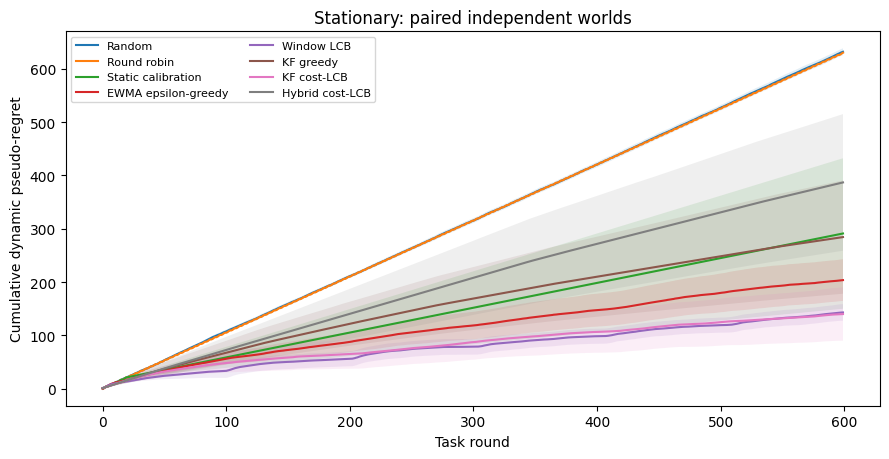

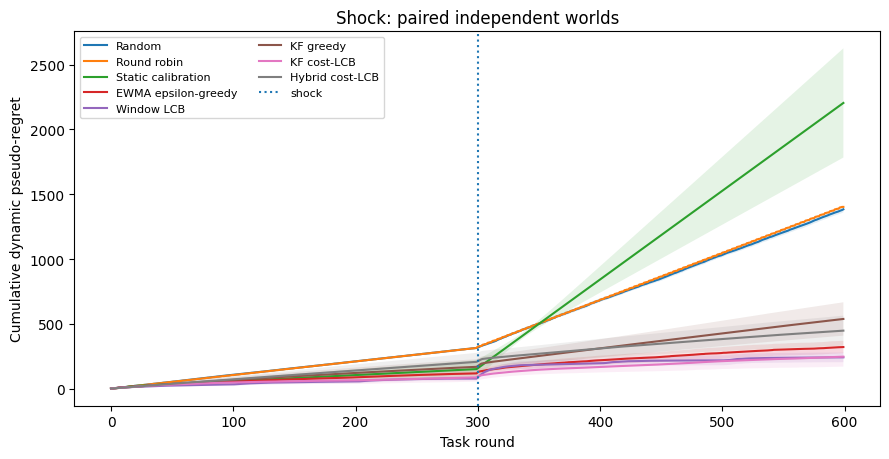

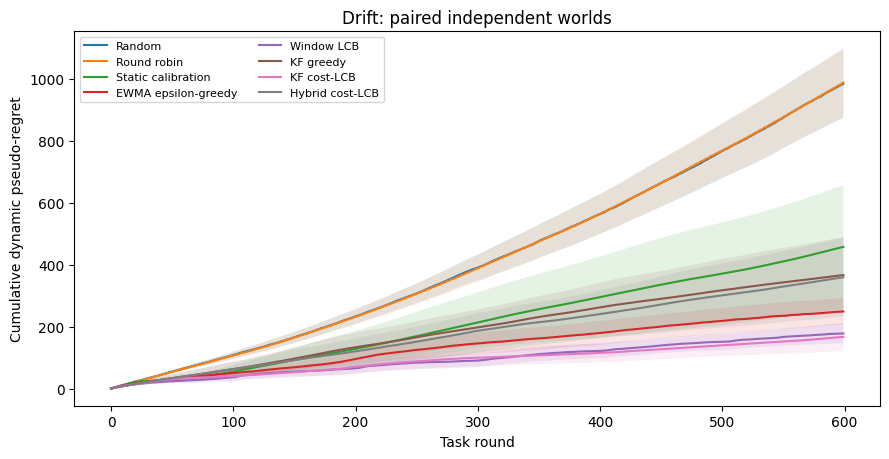

,scenario,candidate,reference,n_pairs,mean_difference,lower_95,upper_95
0,stationary,KF cost-LCB,EWMA epsilon-greedy,32,-63.659,-125.995,-1.323
1,shock,KF cost-LCB,EWMA epsilon-greedy,32,-74.175,-168.082,19.732
2,drift,KF cost-LCB,EWMA epsilon-greedy,32,-81.917,-146.363,-17.471


,scenario,candidate,reference,n_pairs,mean_difference,lower_95,upper_95
0,stationary,KF cost-LCB,Window LCB,32,-3.016,-50.092,44.061
1,shock,KF cost-LCB,Window LCB,32,5.203,-67.613,78.020
2,drift,KF cost-LCB,Window LCB,32,-10.897,-46.715,24.921


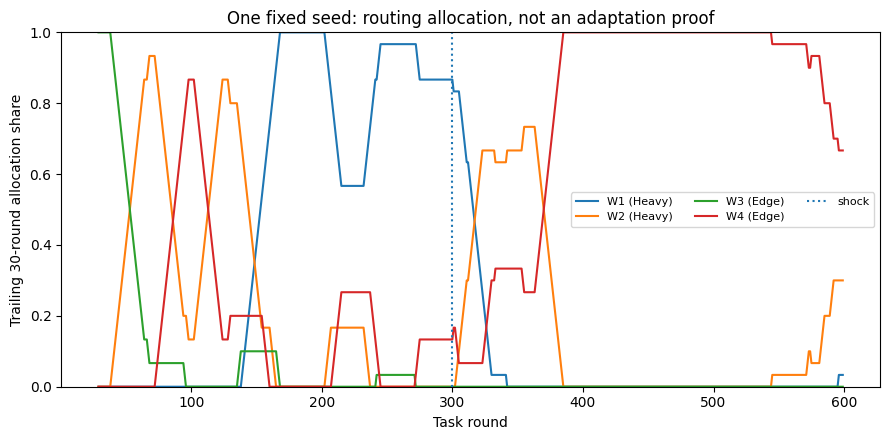

In [9]:
benchmark_results, benchmark_curves = benchmark()
benchmark_summary = summarize(benchmark_results)
display(benchmark_summary.round(3))
for scenario in ("stationary", "shock", "drift"):
    plot_regret(benchmark_curves, scenario)
display(paired_differences(benchmark_results, "KF cost-LCB", "EWMA epsilon-greedy").round(3))
display(paired_differences(benchmark_results, "KF cost-LCB", "Window LCB").round(3))


example_world = make_world(TEST_SEEDS[0], "shock")
example_result = run_policy(example_world, PolicySpec("KF cost-LCB"), TEST_SEEDS[0], detailed=True)
figure, axis = plt.subplots(figsize=(9, 4.5))
for peer, name in enumerate(PEER_NAMES):
    share = pd.Series(example_result["action"] == peer).rolling(30, min_periods=30).mean()
    axis.plot(share, label=name)
axis.axvline(HORIZON // 2, linestyle=":", label="shock")
axis.set(xlabel="Task round", ylabel="Trailing 30-round allocation share", ylim=(0, 1),
         title="One fixed seed: routing allocation, not an adaptation proof")
axis.legend(ncol=3, fontsize=8)
figure.tight_layout()
plt.show()

## Part 4. Calibration under matched and misspecified likelihoods

**Question.** Are the uncertainty estimates numerically and statistically meaningful, independently of routing reward?

First, a separate unconstrained linear-Gaussian problem exactly matches the filtering assumptions. Its two coordinates are generic real-valued states, **not physical latency and failure probability**. True initial states are drawn from the stated Gaussian prior. Only one adaptively chosen peer is observed each round. Final-time diagnostics use 2,500 independent worlds, avoiding dependence between repeated measurements within one trajectory.

$$\operatorname{NEES}=(\hat x-x)^\top P^{-1}(\hat x-x),\qquad
\operatorname{NIS}=(z-\hat x^-)^\top(P^-+R)^{-1}(z-\hat x^-).$$

For two-dimensional correctly specified Gaussian models, their expected value is 2, and NIS has a $\chi^2_2$ reference distribution. NEES is first averaged over peers within each world. Marginal 95% Gaussian intervals should achieve approximately 95% coverage, within Monte Carlo uncertainty. Underestimating and overestimating $Q$ provide deliberately misspecified controls.

Next, stationary Beta-Bernoulli coverage is checked under its own prior-predictive model. Finally, the real routing observation generator is audited with a **common round-robin schedule** for every estimator, so estimator comparisons are not confounded by different selected peers. Gaussian and discounted-Beta interval coverage, interval width, probability RMSE, pre-outcome Brier score, and excess Brier score are reported. Excess Brier here is $(\hat\eta-\eta)^2$, available only because the simulation exposes truth to the evaluator. Interval/RMSE summaries exclude the first 100 rounds; proper-score summaries include the whole horizon.

**Analysis task.** Distinguish correct Gaussian implementation from correct modeling of binary failures. Check whether improved coverage merely reflects wider intervals. A discounted Beta distribution respects probability support but does not, by itself, establish calibrated uncertainty after a shock.

,Q multiplier,diagnostic,target,mean,lower_95,upper_95
0,0.1,NEES,2.00,7.3787,7.2069,7.5504
1,0.1,NIS,2.00,2.4546,2.3570,2.5522
2,0.1,marginal coverage,0.95,0.7192,0.7129,0.7255
3,1.0,NEES,2.00,2.0322,1.9931,2.0714
4,1.0,NIS,2.00,2.0329,1.9529,2.1130
5,1.0,marginal coverage,0.95,0.9494,0.9464,0.9525
6,10.0,NEES,2.00,0.6537,0.6366,0.6709
7,10.0,NIS,2.00,1.5630,1.5027,1.6234
8,10.0,marginal coverage,0.95,0.9950,0.9940,0.9959


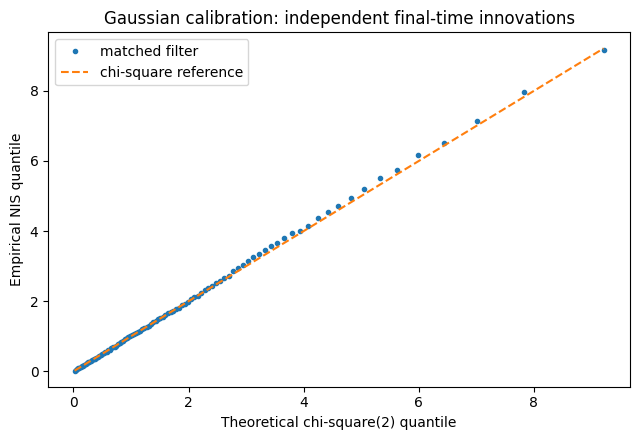

Stationary Beta-Bernoulli prior-predictive coverage: (0.9512, np.float64(0.9469765416817852), np.float64(0.9554234583182148))


all_peer_coverage  ...  excess_brier
scenario   policy                                   ...              
stationary KF cost-LCB                      0.9930  ...        0.0181
           Hybrid discounted                0.9881  ...        0.0121
           Hybrid no forgetting             0.9322  ...        0.0050
shock      KF cost-LCB                      0.9856  ...        0.0201
           Hybrid discounted                0.9591  ...        0.0172
           Hybrid no forgetting             0.6600  ...        0.0479

[6 rows x 5 columns]

,scenario,policy,n,metric,mean,lower_95,upper_95
0,stationary,KF cost-LCB,16,all_peer_coverage,0.9930,0.9910,0.9950
1,stationary,Hybrid discounted,16,all_peer_coverage,0.9881,0.9823,0.9939
2,stationary,Hybrid no forgetting,16,all_peer_coverage,0.9322,0.8916,0.9729
3,shock,KF cost-LCB,16,all_peer_coverage,0.9856,0.9824,0.9887
4,shock,Hybrid discounted,16,all_peer_coverage,0.9591,0.9504,0.9677
5,shock,Hybrid no forgetting,16,all_peer_coverage,0.6600,0.6279,0.6922


In [10]:
def gaussian_calibration(q_scale: float, replications: int = 2500, steps: int = 100):
    """testing adaptive partial-observation filtering under an exactly matched Gaussian model."""
    rng = seeded_rng(4000, 40)
    peers, dimension = 4, 2
    prior_variance = np.array([.5, .25])
    process_variance = np.array([.005, .002])
    observation_variance = np.array([.20, .15])
    truth = rng.normal(size=(replications, peers, dimension)) * np.sqrt(prior_variance)
    estimate = np.zeros_like(truth)
    variance = np.broadcast_to(prior_variance, truth.shape).copy()
    row = np.arange(replications)
    final_nis = None
    for time in range(steps):
        if time:
            truth += rng.normal(size=truth.shape) * np.sqrt(process_variance)
            variance += q_scale * process_variance
        score = estimate[..., 0] + 8 * estimate[..., 1] - .5 * np.sqrt(variance[..., 0] + 64 * variance[..., 1])
        choice = np.argmin(score, axis=1)
        observations = truth + rng.normal(size=truth.shape) * np.sqrt(observation_variance)
        prior = variance[row, choice].copy()
        innovation = observations[row, choice] - estimate[row, choice]
        final_nis = np.sum(innovation**2 / (prior + observation_variance), axis=1)
        gain = prior / (prior + observation_variance)
        estimate[row, choice] += gain * innovation
        variance[row, choice] = (1 - gain)**2 * prior + gain**2 * observation_variance
    error = estimate - truth
    nees = np.sum(error**2 / variance, axis=-1).mean(axis=1)
    coverage = (np.abs(error) <= norm.ppf(.975) * np.sqrt(variance)).mean(axis=(1, 2))
    rows = []
    for name, samples, target in (("NEES", nees, 2.0), ("NIS", final_nis, 2.0), ("marginal coverage", coverage, .95)):
        mean, lower, upper = mean_interval(samples)
        rows.append({"Q multiplier": q_scale, "diagnostic": name, "target": target,
                     "mean": mean, "lower_95": lower, "upper_95": upper})
    return pd.DataFrame(rows), final_nis


calibration_parts, matched_nis = [], None
for q_multiplier in (.1, 1., 10.):
    table, nis_values = gaussian_calibration(q_multiplier)
    calibration_parts.append(table)
    if q_multiplier == 1.:
        matched_nis = nis_values
gaussian_diagnostics = pd.concat(calibration_parts, ignore_index=True)
display(gaussian_diagnostics.round(4))

quantiles = np.linspace(.01, .99, 99)
figure, axis = plt.subplots(figsize=(6.5, 4.5))
axis.plot(chi2.ppf(quantiles, df=2), np.quantile(matched_nis, quantiles), marker=".", linestyle="none", label="matched filter")
reference = chi2.ppf([.01, .99], df=2)
axis.plot(reference, reference, linestyle="--", label="chi-square reference")
axis.set(xlabel="Theoretical chi-square(2) quantile", ylabel="Empirical NIS quantile", title="Gaussian calibration: independent final-time innovations")
axis.legend()
figure.tight_layout()
plt.show()


bernoulli_rng = seeded_rng(4001, 40)
prior_probabilities = bernoulli_rng.beta(1., 1., size=10000)
failures = bernoulli_rng.binomial(100, prior_probabilities)
lower = beta_distribution.ppf(.025, 1 + failures, 101 - failures)
upper = beta_distribution.ppf(.975, 1 + failures, 101 - failures)
beta_coverage = (lower <= prior_probabilities) & (prior_probabilities <= upper)
print("Stationary Beta-Bernoulli prior-predictive coverage:", mean_interval(beta_coverage))


CALIBRATION_POLICIES = (
    PolicySpec("KF cost-LCB"),
    PolicySpec("Hybrid discounted", "hybrid"),
    PolicySpec("Hybrid no forgetting", "hybrid", discount=1., q_scale=0.),
)
audit_rows = []
for scenario in ("stationary", "shock"):
    for seed in STRESS_SEEDS:
        world = make_world(seed, scenario)
        audit_actions = np.arange(world.steps) % world.peers
        truth = world.means[np.arange(world.steps), :, world.contexts, 1]
        for spec in CALIBRATION_POLICIES:
            result = run_policy(world, spec, seed, detailed=True, forced_actions=audit_actions)
            start = 100
            intervals = result["intervals"][start:]
            coverage = (intervals[..., 0] <= truth[start:]) & (truth[start:] <= intervals[..., 1])
            audit_rows.append(result["summary"] | {
                "all_peer_coverage": coverage.mean(),
                "interval_width": np.mean(intervals[..., 1] - intervals[..., 0]),
                "probability_rmse": np.sqrt(np.mean((result["estimates"][start:, :, 1] - truth[start:])**2)),
            })
audit_results = pd.DataFrame(audit_rows)
display(audit_results.groupby(["scenario", "policy"], sort=False)[
    ["all_peer_coverage", "interval_width", "probability_rmse", "brier", "excess_brier"]
].mean().round(4))
display(summarize(audit_results, "all_peer_coverage").round(4))

## Part 5. Mechanism ablations and validation-selected comparisons

**Question.** Which component causes any observed improvement, and does it survive fairer parameter selection?

Ablations remove elapsed-time aging, replace cost-projected uncertainty by trace uncertainty, remove exploration, or set process noise to zero. The aging/trace combinations form a small factorial comparison. They share the default coefficient rather than being separately optimized; the trace ablation changes the effective bonus scale and cannot alone prove the projected score is performance-optimal. The covariance projection is justified dimensionally, regardless of the outcome.

Each of four policy families then receives **nine candidate configurations**, each evaluated on the same 12 validation seeds in all three main scenarios. Selection minimizes the equally weighted average total regret across scenarios and validation seeds. All candidates are displayed through `CANDIDATE_FAMILIES`; no test feedback enters selection. The selected configurations are evaluated on **32 new confirmation seeds**, disjoint from the earlier baseline, validation, and stress sets.

KF candidates vary $\beta$ and $Q$ scale; hybrid candidates vary $\beta$ and forgetting; EWMA candidates vary exploration and step size; window candidates vary optimism and window length. Equal grid counts are a controlled search budget, not proof of equally exhaustive optimization. The 3-by-3 KF sensitivity table is validation-only, not a global sensitivity analysis or a full phase diagram.

**Analysis task.** Report unfavorable ablations and strong baselines as findings. Check whether the parameter setting that looks best on abrupt changes also behaves reasonably under stationary conditions. Confidence intervals quantify the current sampling error; no fixed seed count automatically makes an experiment publication-grade.

,scenario,candidate,reference,n_pairs,mean_difference,lower_95,upper_95
0,shock,KF no aging,KF cost-LCB,16,132.381,-53.877,318.640
1,recovery,KF no aging,KF cost-LCB,16,59.387,-18.637,137.412
2,shock,KF trace bonus,KF cost-LCB,16,123.913,-43.703,291.528
3,recovery,KF trace bonus,KF cost-LCB,16,61.119,1.163,121.075
4,shock,KF no aging + trace,KF cost-LCB,16,280.175,65.634,494.716
5,recovery,KF no aging + trace,KF cost-LCB,16,80.512,14.087,146.938
6,shock,KF no exploration,KF cost-LCB,16,401.731,235.665,567.798
7,recovery,KF no exploration,KF cost-LCB,16,104.419,40.249,168.588
8,shock,KF zero Q,KF cost-LCB,16,549.281,330.997,767.566
9,recovery,KF zero Q,KF cost-LCB,16,312.525,217.281,407.769


,family,candidates,selected configuration,validation mean regret
0,KF,9,"KF beta=1.5, Q=0.1",107.149016
1,Hybrid,9,"Hybrid beta=1.5, discount=0.995",97.485493
2,EWMA,9,"EWMA epsilon=0.02, alpha=0.05",158.984812
3,Window,9,"Window beta=0.03, window=100",168.253436


,scenario,policy,n,metric,mean,lower_95,upper_95
0,stationary,KF validation-selected,32,regret,99.875,68.955,130.795
1,stationary,Hybrid validation-selected,32,regret,69.359,44.655,94.064
2,stationary,EWMA validation-selected,32,regret,129.366,67.589,191.143
3,stationary,Window validation-selected,32,regret,120.806,101.474,140.139
4,shock,KF validation-selected,32,regret,161.409,113.473,209.346
5,shock,Hybrid validation-selected,32,regret,70.519,44.881,96.156
6,shock,EWMA validation-selected,32,regret,397.897,292.228,503.566
7,shock,Window validation-selected,32,regret,245.844,203.125,288.563
8,drift,KF validation-selected,32,regret,126.801,87.680,165.923
9,drift,Hybrid validation-selected,32,regret,133.129,98.754,167.503


,scenario,candidate,reference,n_pairs,mean_difference,lower_95,upper_95
0,stationary,KF validation-selected,Hybrid validation-selected,32,30.516,8.698,52.333
1,shock,KF validation-selected,Hybrid validation-selected,32,90.891,39.662,142.120
2,drift,KF validation-selected,Hybrid validation-selected,32,-6.328,-35.497,22.842
3,stationary,KF validation-selected,EWMA validation-selected,32,-29.491,-82.744,23.763
4,shock,KF validation-selected,EWMA validation-selected,32,-236.488,-332.038,-140.937
5,drift,KF validation-selected,EWMA validation-selected,32,-100.711,-162.729,-38.693
6,stationary,KF validation-selected,Window validation-selected,32,-20.931,-45.149,3.286
7,shock,KF validation-selected,Window validation-selected,32,-84.434,-156.420,-12.449
8,drift,KF validation-selected,Window validation-selected,32,-49.407,-82.387,-16.426


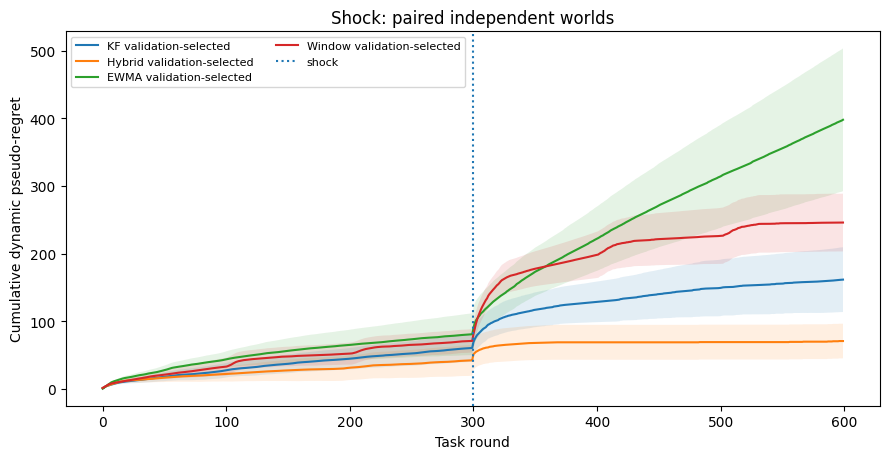

beta,0.1,0.5,1.5
Q multiplier,,,
0.1,591.32,512.60,107.15
1.0,516.58,157.67,239.73
10.0,243.15,271.79,442.52


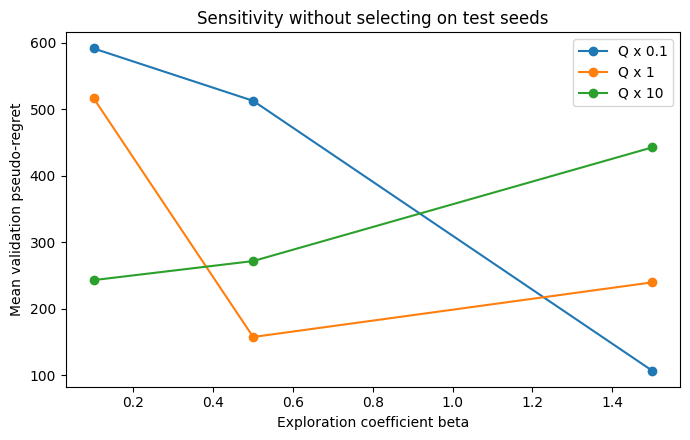

In [11]:
ABLATIONS = (
    PolicySpec("KF cost-LCB"),
    PolicySpec("KF no aging", aging=False),
    PolicySpec("KF trace bonus", uncertainty="trace"),
    PolicySpec("KF no aging + trace", aging=False, uncertainty="trace"),
    PolicySpec("KF no exploration", beta=0.),
    PolicySpec("KF zero Q", q_scale=0.),
)
ablation_results, _ = benchmark(ABLATIONS, scenarios=("shock", "recovery"), seeds=STRESS_SEEDS)
ablation_effects = pd.concat([
    paired_differences(ablation_results, spec.name, "KF cost-LCB")
    for spec in ABLATIONS[1:]
], ignore_index=True)
display(ablation_effects.round(3))


CANDIDATE_FAMILIES = {
    "KF": [PolicySpec(f"KF beta={beta:g}, Q={q:g}", beta=beta, q_scale=q)
           for beta in (.1, .5, 1.5) for q in (.1, 1., 10.)],
    "Hybrid": [PolicySpec(f"Hybrid beta={beta:g}, discount={discount:g}", "hybrid", beta=beta, discount=discount)
               for beta in (.1, .5, 1.5) for discount in (.90, .97, .995)],
    "EWMA": [PolicySpec(f"EWMA epsilon={epsilon:g}, alpha={alpha:g}", "ewma", epsilon=epsilon, alpha=alpha)
             for epsilon in (.02, .10, .30) for alpha in (.05, .15, .40)],
    "Window": [PolicySpec(f"Window beta={beta:g}, window={window}", "window", beta=beta, window=window)
               for beta in (.03, .10, .30) for window in (30, 100, 250)],
}
validation_policies = tuple(spec for family in CANDIDATE_FAMILIES.values() for spec in family)
validation_results, _ = benchmark(validation_policies, seeds=VALIDATION_SEEDS)
validation_ranking = validation_results.groupby("policy")["regret"].mean().sort_values()
selected_policies, selection_rows = [], []
for family, candidates in CANDIDATE_FAMILIES.items():
    winner = min(candidates, key=lambda spec: (validation_ranking[spec.name], spec.name))
    selected_policies.append(replace(winner, name=f"{family} validation-selected"))
    selection_rows.append({"family": family, "candidates": len(candidates),
                           "selected configuration": winner.name,
                           "validation mean regret": validation_ranking[winner.name]})
selection_table = pd.DataFrame(selection_rows)
display(selection_table)


selected_policies = tuple(selected_policies)
selected_test_results, selected_test_curves = benchmark(selected_policies, seeds=CONFIRMATION_SEEDS)
display(summarize(selected_test_results).round(3))
selected_effects = pd.concat([
    paired_differences(selected_test_results, "KF validation-selected", reference)
    for reference in ("Hybrid validation-selected", "EWMA validation-selected", "Window validation-selected")
], ignore_index=True)
display(selected_effects.round(3))
plot_regret(selected_test_curves, "shock")


sensitivity_rows = []
for candidate in CANDIDATE_FAMILIES["KF"]:
    sensitivity_rows.append({"beta": candidate.beta, "Q multiplier": candidate.q_scale,
                             "validation regret": validation_ranking[candidate.name]})
sensitivity_table = pd.DataFrame(sensitivity_rows).pivot(index="Q multiplier", columns="beta", values="validation regret")
display(sensitivity_table.round(2))
figure, axis = plt.subplots(figsize=(7, 4.5))
for q_multiplier in sensitivity_table.index:
    axis.plot(sensitivity_table.columns, sensitivity_table.loc[q_multiplier], marker="o", label=f"Q x {q_multiplier:g}")
axis.set(xlabel="Exploration coefficient beta", ylabel="Mean validation pseudo-regret", title="Sensitivity without selecting on test seeds")
axis.legend()
figure.tight_layout()
plt.show()

## Part 6. Feedback delay, missing verification, and recovery

**Question.** Does useful routing adaptation survive stale or missing observations?

The validation-selected policies are held fixed. A factorial test varies extra feedback delay over 0, 5, and 20 rounds and independent verification-payload loss over 0% and 30%. Tasks still incur their true latency and failure costs when feedback is missing. Missing feedback is **not** converted into a success, a failure, or a zero-cost observation. Observations sampled during the blackout interval are permanently unavailable; previously sampled delayed observations can still arrive. The blackout does not itself fail workers or remove routing eligibility.

A separate shock test removes feedback from 25 rounds before the change to 50 rounds after it. A recovery test first degrades W1 and then restores it. These are knowledge-loss experiments, not simulations of a network partition's execution consequences.

Adaptation is the first **complete 20-round post-change window** with at least 80% optimal-peer selections. The reported lag is the window's ending time relative to the event, so its minimum is 20 rounds. A run not crossing the threshold before the next event/horizon is assigned that full observation window and marked `adapted=0`. Capped mean delay and adaptation fraction are both reported. This is a finite-window first-passage endpoint, not an uncensored mean recovery time or proof of sustained adaptation.

**Analysis task.** Compare degradation detection, replacement discovery, and rediscovery of a recovered peer. Check whether aggressive aging helps during feedback gaps or instead spends too many tasks exploring peers that cannot yet be verified.

,delay,feedback_loss,policy,n,metric,mean,lower_95,upper_95
0,0,0.0,KF validation-selected,16,regret,144.200,96.399,192.001
1,0,0.0,Hybrid validation-selected,16,regret,103.538,65.047,142.028
2,0,0.0,EWMA validation-selected,16,regret,350.731,193.992,507.470
3,0,0.0,Window validation-selected,16,regret,279.900,197.502,362.298
4,0,0.3,KF validation-selected,16,regret,157.238,102.382,212.093
5,0,0.3,Hybrid validation-selected,16,regret,77.331,46.430,108.233
6,0,0.3,EWMA validation-selected,16,regret,512.131,361.225,663.037
7,0,0.3,Window validation-selected,16,regret,298.594,224.833,372.355
8,5,0.0,KF validation-selected,16,regret,261.700,197.533,325.867
9,5,0.0,Hybrid validation-selected,16,regret,214.031,144.283,283.780


capped_adaptation_rounds  ...  delivered_fraction
delay feedback_loss policy                                                ...                    
0     0.0           KF validation-selected                        38.500  ...               1.000
                    Hybrid validation-selected                    38.375  ...               1.000
                    EWMA validation-selected                     143.938  ...               1.000
                    Window validation-selected                    55.438  ...               1.000
      0.3           KF validation-selected                        37.062  ...               0.695
                    Hybrid validation-selected                    22.875  ...               0.695
                    EWMA validation-selected                     159.438  ...               0.687
                    Window validation-selected                    49.500  ...               0.701
5     0.0           KF validation-selected                        58.188  ...               0.992
                    Hybrid validation-selected                    54.812  ...               0.992
                    EWMA validation-selected                     174.625  ...               0.992
                    Window validation-selected                    54.188  ...               0.992
      0.3           KF validation-selected                        46.562  ...               0.688
                    Hybrid validation-selected                    42.938  ...               0.686
                    EWMA validation-selected                     178.562  ...               0.680
                    Window validation-selected                    60.500  ...               0.691
20    0.0           KF validation-selected                        64.500  ...               0.967
                    Hybrid validation-selected                    64.125  ...               0.967
                    EWMA validation-selected                     192.188  ...               0.967
                    Window validation-selected                    58.250  ...               0.967
      0.3           KF validation-selected                        65.250  ...               0.669
                    Hybrid validation-selected                    75.438  ...               0.670
                    EWMA validation-selected                     174.875  ...               0.671
                    Window validation-selected                    74.438  ...               0.676

[24 rows x 3 columns]

capped_adaptation_rounds  ...   regret
condition                event_round policy                                                ...         
feedback blackout        300         KF validation-selected                       100.812  ...  605.131
                                     Hybrid validation-selected                    98.125  ...  612.012
                                     EWMA validation-selected                     176.000  ...  790.044
                                     Window validation-selected                    76.312  ...  340.275
degradation and recovery 200         KF validation-selected                        73.125  ...  268.888
                         400         KF validation-selected                       125.438  ...  268.888
                         200         Hybrid validation-selected                   111.125  ...  220.719
                         400         Hybrid validation-selected                   106.000  ...  220.719
                         200         EWMA validation-selected                      58.250  ...  337.650
                         400         EWMA validation-selected                     194.500  ...  337.650
                         200         Window validation-selected                    78.938  ...  263.556
                         400         Window validation-selected                    74.812  ...  263.556

[12 rows x 3 columns]

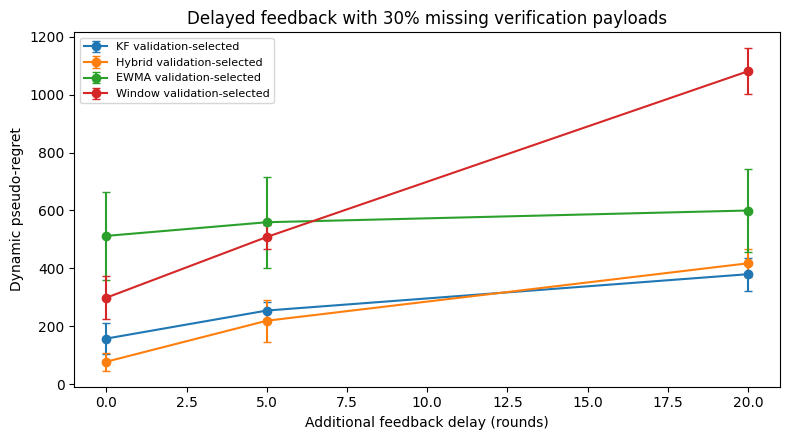

In [12]:
def adaptation_endpoint(optimal_choices, change: int, stop: int, window: int = 20, threshold: float = .8):
    """measuring a capped first-passage delay without dropping non-adapting runs."""
    segment = np.asarray(optimal_choices[change:stop], dtype=float)
    horizon = len(segment)
    if horizon < window:
        return horizon, False
    shares = np.convolve(segment, np.ones(window) / window, mode="valid")
    passed = np.flatnonzero(shares >= threshold - 1e-12)
    return (int(passed[0]) + window, True) if len(passed) else (horizon, False)


feedback_rows = []
feedback_specs = selected_policies
for delay in (0, 5, 20):
    for loss in (0., .3):
        for seed in STRESS_SEEDS:
            world = make_world(seed, "shock")
            for spec in feedback_specs:
                result = run_policy(world, spec, seed, delay=delay, drop_probability=loss)
                lag, adapted = adaptation_endpoint(result["optimal"], HORIZON // 2, HORIZON)
                feedback_rows.append(result["summary"] | {"delay": delay, "feedback_loss": loss,
                                      "capped_adaptation_rounds": lag, "adapted": float(adapted)})
feedback_results = pd.DataFrame(feedback_rows)
display(summarize(feedback_results, groups=("delay", "feedback_loss", "policy")).round(3))
display(feedback_results.groupby(["delay", "feedback_loss", "policy"], sort=False)[
    ["capped_adaptation_rounds", "adapted", "delivered_fraction"]
].mean().round(3))


recovery_rows = []
for seed in STRESS_SEEDS:
    for scenario in ("shock", "recovery"):
        world = make_world(seed, scenario)
        blackout = (HORIZON // 2 - 25, HORIZON // 2 + 50) if scenario == "shock" else None
        for spec in feedback_specs:
            result = run_policy(world, spec, seed, blackout=blackout)
            for index, change in enumerate(world.changes):
                stop = world.changes[index + 1] if index + 1 < len(world.changes) else HORIZON
                lag, adapted = adaptation_endpoint(result["optimal"], change, stop)
                recovery_rows.append(result["summary"] | {"event_round": change,
                                      "capped_adaptation_rounds": lag, "adapted": float(adapted),
                                      "condition": "feedback blackout" if blackout else "degradation and recovery"})
recovery_results = pd.DataFrame(recovery_rows)
display(recovery_results.groupby(["condition", "event_round", "policy"], sort=False)[
    ["capped_adaptation_rounds", "adapted", "regret"]
].mean().round(3))


figure, axis = plt.subplots(figsize=(8, 4.5))
for name, group in feedback_results.loc[feedback_results.feedback_loss == .3].groupby("policy", sort=False):
    summaries = summarize(group, groups=("delay",)).sort_values("delay")
    axis.errorbar(summaries["delay"], summaries["mean"],
                  yerr=summaries["upper_95"] - summaries["mean"], marker="o", capsize=3, label=name)
axis.set(xlabel="Additional feedback delay (rounds)", ylabel="Dynamic pseudo-regret", title="Delayed feedback with 30% missing verification payloads")
axis.legend(fontsize=8)
figure.tight_layout()
plt.show()

## Part 7. Task-dependent capabilities versus pooled peer reputation

**Question.** Is one global reliability estimate per peer enough when peers specialize in different tasks?

This explicitly extends the original model. Two observable task types have different peer-specific failure probabilities. The environment's capability table is fixed, while the arrival probability of task type 0 changes from 0.50 to 0.85 halfway through the run. All policies receive the current type. A pooled policy ignores it; a contextual policy maintains one belief per peer and task type. There is no learned task embedding or generalization to unseen task types.

The KF, hybrid, and EWMA configurations selected on the single-context validation experiments are frozen and tested on 16 independent stress seeds. This tests transfer, not contextual hyperparameter optimality. Both aggregate regret and per-context regret per task are reported, preventing the more common task type from hiding poor behavior on the rarer one. All peers remain eligible for both task types.

**Analysis task.** Identify when pooling mixes incompatible capability estimates. Discuss the larger state and sampling budget required by contextual beliefs, particularly after the task-mixture shift. The policy belief state scales as $O(NC)$ for $N$ peers and $C$ task types; no runtime scaling experiment is claimed.

,scenario,policy,n,metric,mean,lower_95,upper_95
0,contextual,KF pooled,16,regret,685.494,664.232,706.756
1,contextual,KF contextual,16,regret,81.944,61.614,102.273
2,contextual,Hybrid pooled,16,regret,716.638,672.889,760.386
3,contextual,Hybrid contextual,16,regret,99.331,62.411,136.252
4,contextual,EWMA pooled,16,regret,720.500,673.185,767.815
5,contextual,EWMA contextual,16,regret,193.081,79.291,306.871


,scenario,candidate,reference,n_pairs,mean_difference,lower_95,upper_95
0,contextual,KF contextual,KF pooled,16,-603.550,-622.806,-584.294
1,contextual,Hybrid contextual,Hybrid pooled,16,-617.306,-679.164,-555.449
2,contextual,EWMA contextual,EWMA pooled,16,-527.419,-630.432,-424.405


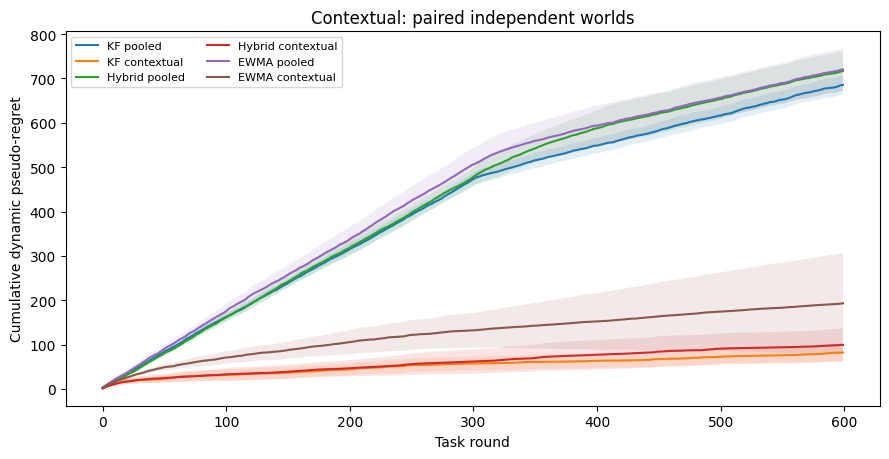

,context,policy,n,metric,mean,lower_95,upper_95
0,0,KF pooled,16,regret_per_task,0.818,0.629,1.008
1,1,KF pooled,16,regret_per_task,1.832,1.499,2.165
2,0,KF contextual,16,regret_per_task,0.113,0.073,0.153
3,1,KF contextual,16,regret_per_task,0.185,0.124,0.246
4,0,Hybrid pooled,16,regret_per_task,0.896,0.669,1.124
5,1,Hybrid pooled,16,regret_per_task,1.842,1.545,2.140
6,0,Hybrid contextual,16,regret_per_task,0.157,0.102,0.213
7,1,Hybrid contextual,16,regret_per_task,0.181,0.073,0.290
8,0,EWMA pooled,16,regret_per_task,0.728,0.551,0.904
9,1,EWMA pooled,16,regret_per_task,2.208,1.797,2.619


In [13]:
context_policies = tuple(
    replace(spec, name=f"{spec.name.split()[0]} {'contextual' if use_context else 'pooled'}", contextual=use_context)
    for spec in selected_policies if spec.kind in {"kalman", "hybrid", "ewma"}
    for use_context in (False, True)
)
context_results, context_curves = benchmark(context_policies, scenarios=("contextual",), seeds=STRESS_SEEDS)
display(summarize(context_results).round(3))
context_effects = pd.concat([
    paired_differences(context_results, f"{family} contextual", f"{family} pooled")
    for family in ("KF", "Hybrid", "EWMA")
], ignore_index=True)
display(context_effects.round(3))
plot_regret(context_curves, "contextual")


context_detail_rows = []
for seed in STRESS_SEEDS:
    world = make_world(seed, "contextual")
    for spec in context_policies:
        result = run_policy(world, spec, seed)
        for context in (0, 1):
            mask = world.contexts == context
            context_detail_rows.append({"seed": seed, "policy": spec.name, "context": context,
                                       "tasks": int(mask.sum()), "regret_per_task": result["regret"][mask].mean(),
                                       "optimal_share": result["optimal"][mask].mean()})
context_detail_results = pd.DataFrame(context_detail_rows)
display(summarize(context_detail_results, "regret_per_task", groups=("context", "policy")).round(3))

## Part 8. Interpreting the latency-reliability trade-off

**Question.** What objective does the router actually optimize, and how much of its behavior is chosen by $\lambda$?

For two fixed peers, the expected-cost crossover satisfies

$$\lambda^*=\frac{l_j-l_i}{\eta_i-\eta_j},\quad \eta_i\ne\eta_j.$$

For the original stationary peer means, W3 is optimal below $\lambda=2$, W4 between 2 and 2.8, and W1 above 2.8, with ties at the boundaries. W2 is dominated by W1 in both mean latency and failure probability. These facts are consequences of the supplied parameters, not learned discoveries.

The selected policies are evaluated over seven penalties using the same paired worlds. The figure displays expected latency against expected failure probability, separately from the combined score. The plotted policy curves are finite-horizon operating points; they are **not** a proven Pareto frontier. Parameters are not retuned for each penalty. In the window baseline, the bonus scale includes the heuristic factor $1+\lambda$; this section keeps the original latency unit fixed.

**Analysis task.** Explain whether an apparently better router is exploiting a favorable objective weight. Report both latency and reliability, not only weighted cost. A deployment requiring a hard reliability constraint would need a different constrained decision rule and an independently validated risk model.

,lambda,oracle peer(s),minimum expected cost
0,0.0,W3 (Edge),0.30
1,1.0,W3 (Edge),0.70
2,2.0,"W3 (Edge), W4 (Edge)",1.10
3,2.8,"W1 (Heavy), W4 (Edge)",1.34
4,4.0,W1 (Heavy),1.40
5,8.0,W1 (Heavy),1.60
6,16.0,W1 (Heavy),2.00


,lambda,policy,expected_latency,expected_failure_probability,regret
0,0.0,KF validation-selected,0.3139,0.3940,8.3625
1,0.0,Hybrid validation-selected,0.3166,0.3944,9.9875
2,0.0,EWMA validation-selected,0.3196,0.3940,11.7375
3,0.0,Window validation-selected,0.3269,0.3920,16.1500
4,1.0,KF validation-selected,0.3543,0.3742,17.1094
5,1.0,Hybrid validation-selected,0.3454,0.3799,15.1656
6,1.0,EWMA validation-selected,0.4187,0.3447,38.0531
7,1.0,Window validation-selected,0.4145,0.3492,38.2563
8,2.0,KF validation-selected,0.5436,0.2948,20.0000
9,2.0,Hybrid validation-selected,0.4218,0.3430,4.6062


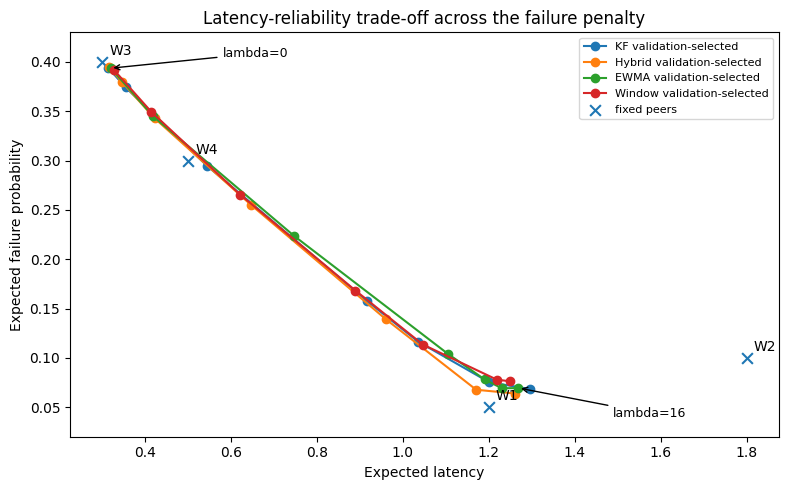

In [14]:
penalty_grid = (0., 1., 2., 2.8, 4., 8., 16.)
base_world = make_world(STRESS_SEEDS[0], "stationary")
base_means = base_world.means[0, :, 0]
frontier_rows = []
for penalty in penalty_grid:
    costs = base_means[:, 0] + penalty * base_means[:, 1]
    optimal_peers = ", ".join(PEER_NAMES[index] for index in np.flatnonzero(np.isclose(costs, costs.min())))
    frontier_rows.append({"lambda": penalty, "oracle peer(s)": optimal_peers, "minimum expected cost": costs.min()})
display(pd.DataFrame(frontier_rows))


tradeoff_rows = []
for penalty in penalty_grid:
    for seed in STRESS_SEEDS:
        world = make_world(seed, "stationary")
        for spec in selected_policies:
            result = run_policy(world, spec, seed, penalty=penalty)
            truth = world.means[np.arange(HORIZON), result["action"], world.contexts]
            tradeoff_rows.append(result["summary"] | {"lambda": penalty,
                                 "expected_latency": truth[:, 0].mean(),
                                 "expected_failure_probability": truth[:, 1].mean()})
tradeoff_results = pd.DataFrame(tradeoff_rows)
tradeoff_summary = tradeoff_results.groupby(["lambda", "policy"], sort=False)[
    ["expected_latency", "expected_failure_probability", "regret"]
].mean().reset_index()
display(tradeoff_summary.round(4))


figure, axis = plt.subplots(figsize=(8, 5))
for name, group in tradeoff_summary.groupby("policy", sort=False):
    group = group.sort_values("lambda")
    axis.plot(group["expected_latency"], group["expected_failure_probability"], marker="o", label=name)
endpoint_means = tradeoff_summary.groupby("lambda")[["expected_latency", "expected_failure_probability"]].mean()
for penalty, label_position in ((0., (.58, .405)), (16., (1.49, .04))):
    point = endpoint_means.loc[penalty]
    axis.annotate(f"lambda={penalty:g}", (point.expected_latency, point.expected_failure_probability),
                  xytext=label_position, arrowprops={"arrowstyle": "->"}, fontsize=9)
axis.scatter(base_means[:, 0], base_means[:, 1], marker="x", s=60, label="fixed peers")
for name, point in zip(PEER_NAMES, base_means):
    axis.annotate(name.split()[0], point, xytext=(5, 5), textcoords="offset points")
axis.set(xlabel="Expected latency", ylabel="Expected failure probability",
         title="Latency-reliability trade-off across the failure penalty", ylim=(.02, .43))
axis.legend(fontsize=8)
figure.tight_layout()
plt.show()

## Scope of the resulting evidence

This notebook supports a reproducible **synthetic study of local, partially observed, nonstationary peer selection**. A defensible paper would make the conditional finding central: which uncertainty representations, aging rules, observation models, and task contexts improve the latency-reliability objective, compared with tuned recency-based alternatives, and under which failures they do not.

The individual ingredients are established filtering and bandit ideas [1–4]. Their combination here does not by itself establish methodological novelty. The strongest empirical contribution would require external worker traces or live task measurements, a precise task-verification protocol, independently estimated observation noise, a broader range of peer populations and drift regimes, and prospective confirmation after the hypotheses and parameter-selection protocol are fixed.

There is no queueing, endogenous load, monetary or energy cost, asynchronous service completion, censored timeout likelihood, correlated worker failure, imperfect verifier, changing neighborhood graph, or multi-router coordination. The simulation's binary outcome is ground-truth failure, not an automatically validated proxy for general model correctness. These are explicit boundaries, not features implied by a topology figure. The code keeps the original two-state interpretation instead of expanding into an unvalidated distributed-system model.

## References

[1] Särkkä, S., and Svensson, L. (2023). *Bayesian Filtering and Smoothing*, 2nd edition. Cambridge University Press. doi:10.1017/9781108917407.

[2] Garivier, A., and Moulines, E. (2011). “On Upper-Confidence Bound Policies for Non-Stationary Bandit Problems.” *Algorithmic Learning Theory*. Preprint arXiv:0805.3415. The window baseline is inspired by this problem family, not a replication of its algorithms or guarantees.

[3] Besbes, O., Gur, Y., and Zeevi, A. (2019). “Optimal Exploration–Exploitation in a Multi-Armed Bandit Problem with Non-Stationary Rewards.” *Stochastic Systems*, 9(4), 319–337. doi:10.1287/stsy.2019.0033.

[4] Russac, Y., Cappé, O., and Garivier, A. (2020). “Algorithms for Non-Stationary Generalized Linear Bandits.” arXiv:2003.10113. Relevant prior art for nonlinear/binary observations; not implemented here.

[5] FilterPy, official `kalman_filter` implementation documentation. Reference for the Joseph covariance update. Accessed 24 September 2026.

[6] TensorFlow Probability, official `LinearGaussianStateSpaceModel` API documentation. Reference for linear-Gaussian state and observation assumptions. Accessed 24 September 2026.

[7] SciPy, official `scipy.stats.beta` API documentation. Reference for Beta distribution moments and quantile evaluation. Accessed 24 September 2026.

## Reproducibility record

The notebook writes no files when run. Its tables, numerical histories, and figures remain in memory or ordinary notebook outputs. The following versions and sample counts document the executed result. Exact environment pins are supplied in `requirements.txt`; Python 3.13.5 was used for the supplied execution.

In [15]:
package_names = ("numpy", "scipy", "pandas", "matplotlib", "networkx", "ipython", "ipykernel")
environment = pd.DataFrame([{"package": "python", "version": platform.python_version()}] +
                           [{"package": package, "version": importlib.metadata.version(package)} for package in package_names])
display(environment)
display(pd.DataFrame({"sample set": ["fixed baselines", "validation", "stress", "confirmation"],
                      "independent seeds": [len(TEST_SEEDS), len(VALIDATION_SEEDS), len(STRESS_SEEDS), len(CONFIRMATION_SEEDS)],
                      "first seed": [TEST_SEEDS[0], VALIDATION_SEEDS[0], STRESS_SEEDS[0], CONFIRMATION_SEEDS[0]],
                      "last seed": [TEST_SEEDS[-1], VALIDATION_SEEDS[-1], STRESS_SEEDS[-1], CONFIRMATION_SEEDS[-1]]}))
assert verification["passed"].all()
print("All verification checks passed. All displayed tables are computed from this execution.")

,package,version
0,python,3.13.5
1,numpy,2.3.5
2,scipy,1.17.0
3,pandas,2.2.3
4,matplotlib,3.10.8
5,networkx,3.6.1
6,ipython,9.14.0
7,ipykernel,7.2.0


,sample set,independent seeds,first seed,last seed
0,fixed baselines,32,1000,1031
1,validation,12,2000,2011
2,stress,16,3000,3015
3,confirmation,32,5000,5031


All verification checks passed. All displayed tables are computed from this execution.
